# Python for Finance Cookbook on Iranian markets

Recipes from chapters 1, 2 and 7 of Eryk Lewinson's *Python for Finance Cookbook*
(Packt, 2020), run on TSETMC, TGJU and SCI data through `yfinance_ir` instead of
Yahoo Finance and Quandl. Same recipe names as the book; the market, the calendar
(Saturday to Wednesday, Iranian holidays) and the currency are the differences.

Prices are Rial and adjusted for dividends and capital increases (see
`docs/conventions.md`). Needs an Iranian IP. Outputs below were produced on the
date printed in the first cell.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import datetime as dt
import warnings

import backtrader as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt

import yfinance_ir as yf

plt.rcParams["figure.figsize"] = (14, 7)
warnings.simplefilter("ignore", FutureWarning)

START, END = "2017-01-01", None
print("run on", dt.date.today(), "| yfinance_ir", yf.__version__)

run on 2026-09-22 | yfinance_ir 2026.9.0


# Chapter 1: Financial data and preprocessing

## 1.1 Getting data (TSETMC instead of Yahoo Finance)

`Ticker("فولاد").history()` is the `yf.download("AAPL")` of the book. TSETMC also
returns `Last` (last trade, distinct from the closing price), traded `Value` and trade
`Count`; those three columns have no Yahoo equivalent.

In [2]:
folad = yf.Ticker("فولاد")
df = folad.history(start=START, end=END)
print(df.shape)
df.tail()

(2120, 10)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Last,Value,Count
Date,,,,,,,,,,
2026-09-15,3144.0,3239.0,3087.0,3223.0,5.883975e+09,0.0,0.0,3239.0,1.896556e+13,25653.0
2026-09-16,3319.0,3319.0,3251.0,3317.0,9.069143e+09,0.0,0.0,3319.0,3.007974e+13,36087.0
2026-09-19,3410.0,3410.0,3220.0,3300.0,6.500954e+09,0.0,0.0,3280.0,2.145268e+13,78299.0
2026-09-20,3210.0,3280.0,3210.0,3210.0,5.563296e+09,0.0,0.0,3220.0,1.788395e+13,56546.0
2026-09-21,3280.0,3300.0,3200.0,3290.0,3.581143e+09,0.0,0.0,3300.0,1.178593e+13,38289.0


### Crypto from Nobitex

`Ticker("BTC-IRT")` needs the `crypto` extra (`ccxt-ir`). Nobitex quotes `*-IRT` pairs
in Toman; the package keeps them in Toman, so never add a crypto column to a Rial
frame without multiplying by 10. It trades seven days a week, so its calendar is
aligned to TSETMC's by inner join wherever the two meet below.

In [3]:
btc = yf.Ticker("BTC-IRT").history(start=START)
eth = yf.Ticker("ETH-IRT").history(start=START)
print("BTC-IRT", btc.shape, btc.index.min().date(), "->", btc.index.max().date())
print("ETH-IRT", eth.shape, eth.index.min().date(), "->", eth.index.max().date())
btc.tail()

BTC-IRT (487, 7) 2025-05-10 -> 2026-09-21
ETH-IRT (485, 7) 2025-05-10 -> 2026-09-21


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-17,1.738706e+10,1.837364e+10,1.734000e+10,1.828773e+10,14.338891,0.0,0.0
2026-09-18,1.824300e+10,1.869000e+10,1.820500e+10,1.847858e+10,14.419648,0.0,0.0
2026-09-19,1.847858e+10,1.865000e+10,1.825011e+10,1.853761e+10,9.906484,0.0,0.0
2026-09-20,1.859350e+10,1.994000e+10,1.850000e+10,1.994000e+10,20.777686,0.0,0.0
2026-09-21,1.994000e+10,1.994000e+10,1.938600e+10,1.971961e+10,7.698477,0.0,0.0


### Trading calendar

The book hardcodes 252 sessions a year. Tehran trades fewer; measure it from the
data rather than assume it, and reuse the number in every annualisation below.

In [4]:
sessions = df.groupby(df.index.year).size()
N_DAYS = int(round(sessions.iloc[1:-1].mean()))  # drop the partial first and last years
print(sessions.to_dict())
print("sessions per year:", N_DAYS)

{2017: 226, 2018: 236, 2019: 233, 2020: 229, 2021: 226, 2022: 227, 2023: 231, 2024: 226, 2025: 221, 2026: 65}
sessions per year: 229


## 1.2 Converting prices to returns

Simple returns aggregate across assets, log returns across time.

In [5]:
rtn = df[["Close"]].copy()
rtn["simple_rtn"] = rtn["Close"].pct_change()
rtn["log_rtn"] = np.log(rtn["Close"] / rtn["Close"].shift(1))
rtn = rtn.dropna()
rtn.head()

,Close,simple_rtn,log_rtn
Date,,,
2017-01-02,25.804526,0.013343,0.013255
2017-01-03,25.823402,0.000732,0.000731
2017-01-04,26.238691,0.016082,0.015954
2017-01-07,26.408582,0.006475,0.006454
2017-01-08,26.446335,0.001430,0.001429


### There's more: inflation-adjusted returns

The book deflates with US CPI from Quandl. `Ticker("CPI")` is the Statistical Centre of
Iran index, one row per Jalali month stamped on the month's first day, so it is
forward-filled onto month ends before dividing.

In [6]:
cpi = yf.Ticker("CPI").history(start=START)["Close"]
monthly = df["Close"].resample("ME").last().to_frame("Close")
monthly["cpi"] = cpi.reindex(monthly.index, method="ffill")
monthly["simple_rtn"] = monthly["Close"].pct_change()
monthly["inflation"] = monthly["cpi"].pct_change()
monthly["real_rtn"] = (1 + monthly["simple_rtn"]) / (1 + monthly["inflation"]) - 1
monthly = monthly.dropna()

total = (1 + monthly[["simple_rtn", "real_rtn"]]).prod() - 1
print(total.map("{:+.1%}".format))
monthly.tail()

simple_rtn    +11274.0%
real_rtn        +508.2%
dtype: str


,Close,cpi,simple_rtn,inflation,real_rtn
Date,,,,,
2025-11-30,2406.220305,435.084401,0.095715,0.042013,0.051537
2025-12-31,3077.017766,469.363895,0.278776,0.078788,0.185382
2026-01-31,2491.967039,513.637392,-0.190136,0.094327,-0.259943
2026-02-28,2548.878589,542.341434,0.022838,0.055884,-0.031297
2026-09-30,3290.000000,700.130356,0.186869,0.000000,0.186869


### There's more: returns in dollars, and against bitcoin

`Ticker("USD")` is TGJU's free-market dollar in Rial. Dividing the Rial series by it
gives the stock in dollars on every trading day. Bitcoin in Toman is divided by the same
dollar (over 10, Toman to Rial) to put both on one axis.

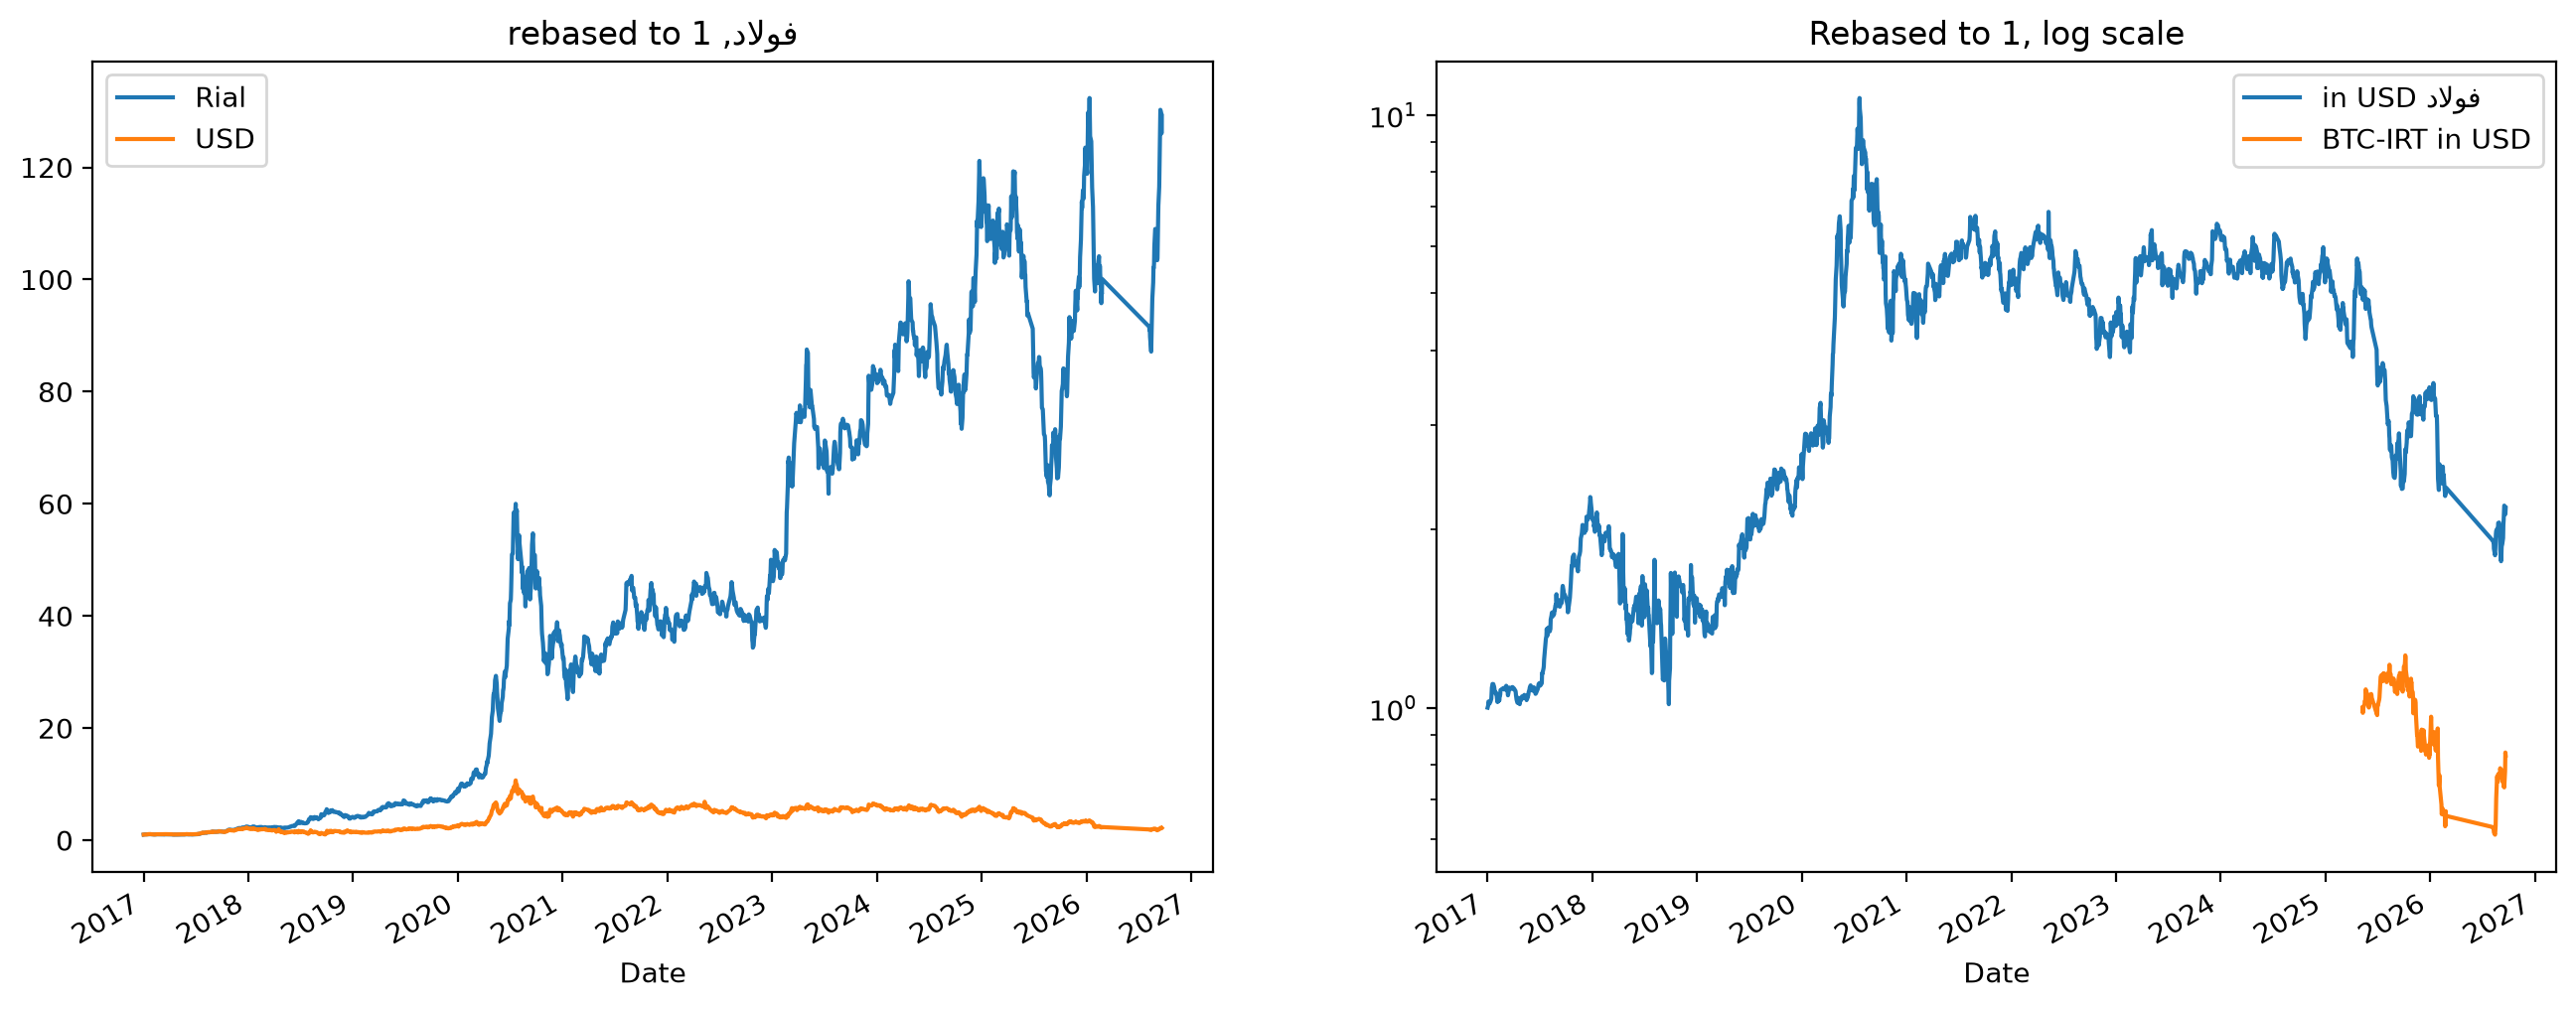

In [7]:
usd = yf.Ticker("USD").history(start=START)["Close"].reindex(df.index, method="ffill")
in_usd = df["Close"] / usd
btc_usd = (btc["Close"] * 10 / usd).dropna()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
(df["Close"] / df["Close"].iloc[0]).plot(ax=ax[0], label="Rial")
(in_usd / in_usd.iloc[0]).plot(ax=ax[0], label="USD")
ax[0].set_title("فولاد, rebased to 1")
ax[0].legend()
(in_usd / in_usd.iloc[0]).plot(ax=ax[1], label="فولاد in USD")
(btc_usd / btc_usd.iloc[0]).plot(ax=ax[1], label="BTC-IRT in USD")
ax[1].set_yscale("log")
ax[1].set_title("Rebased to 1, log scale")
ax[1].legend()
plt.show()

## 1.3 Changing frequency

Monthly realised volatility from daily log returns, annualised with the measured
session count instead of 252.

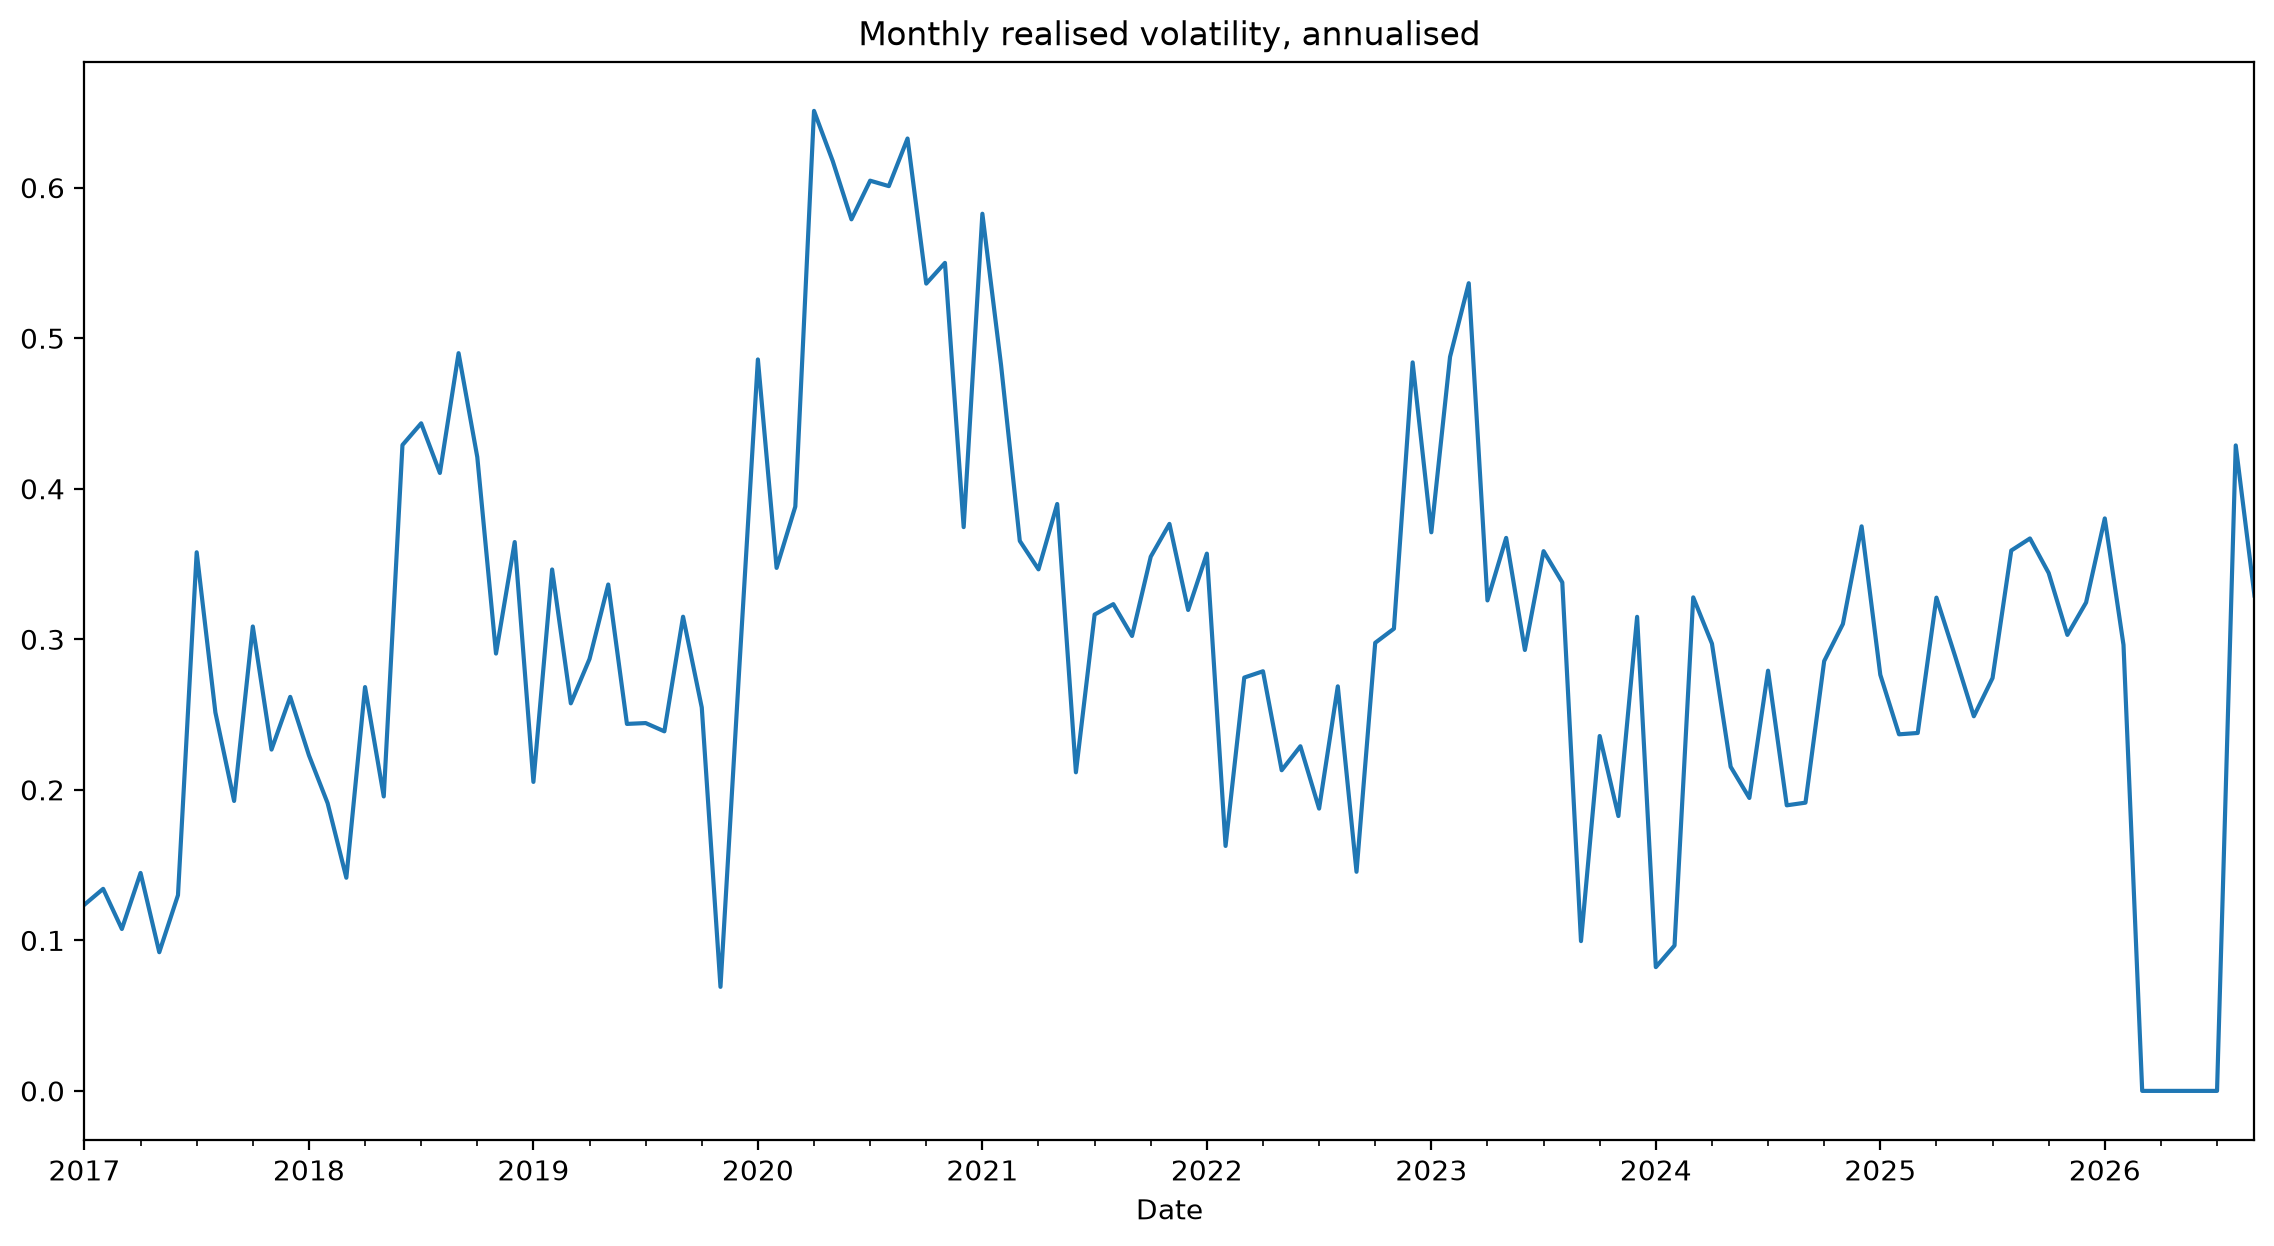

In [8]:
def realized_volatility(x):
    return np.sqrt(np.sum(x ** 2))

rv = rtn["log_rtn"].resample("ME").apply(realized_volatility).to_frame("rv")
rv["rv_annual"] = rv["rv"] * np.sqrt(12)
rv["rv_annual"].plot(title="Monthly realised volatility, annualised")
plt.show()

## 1.4 Visualising time series data

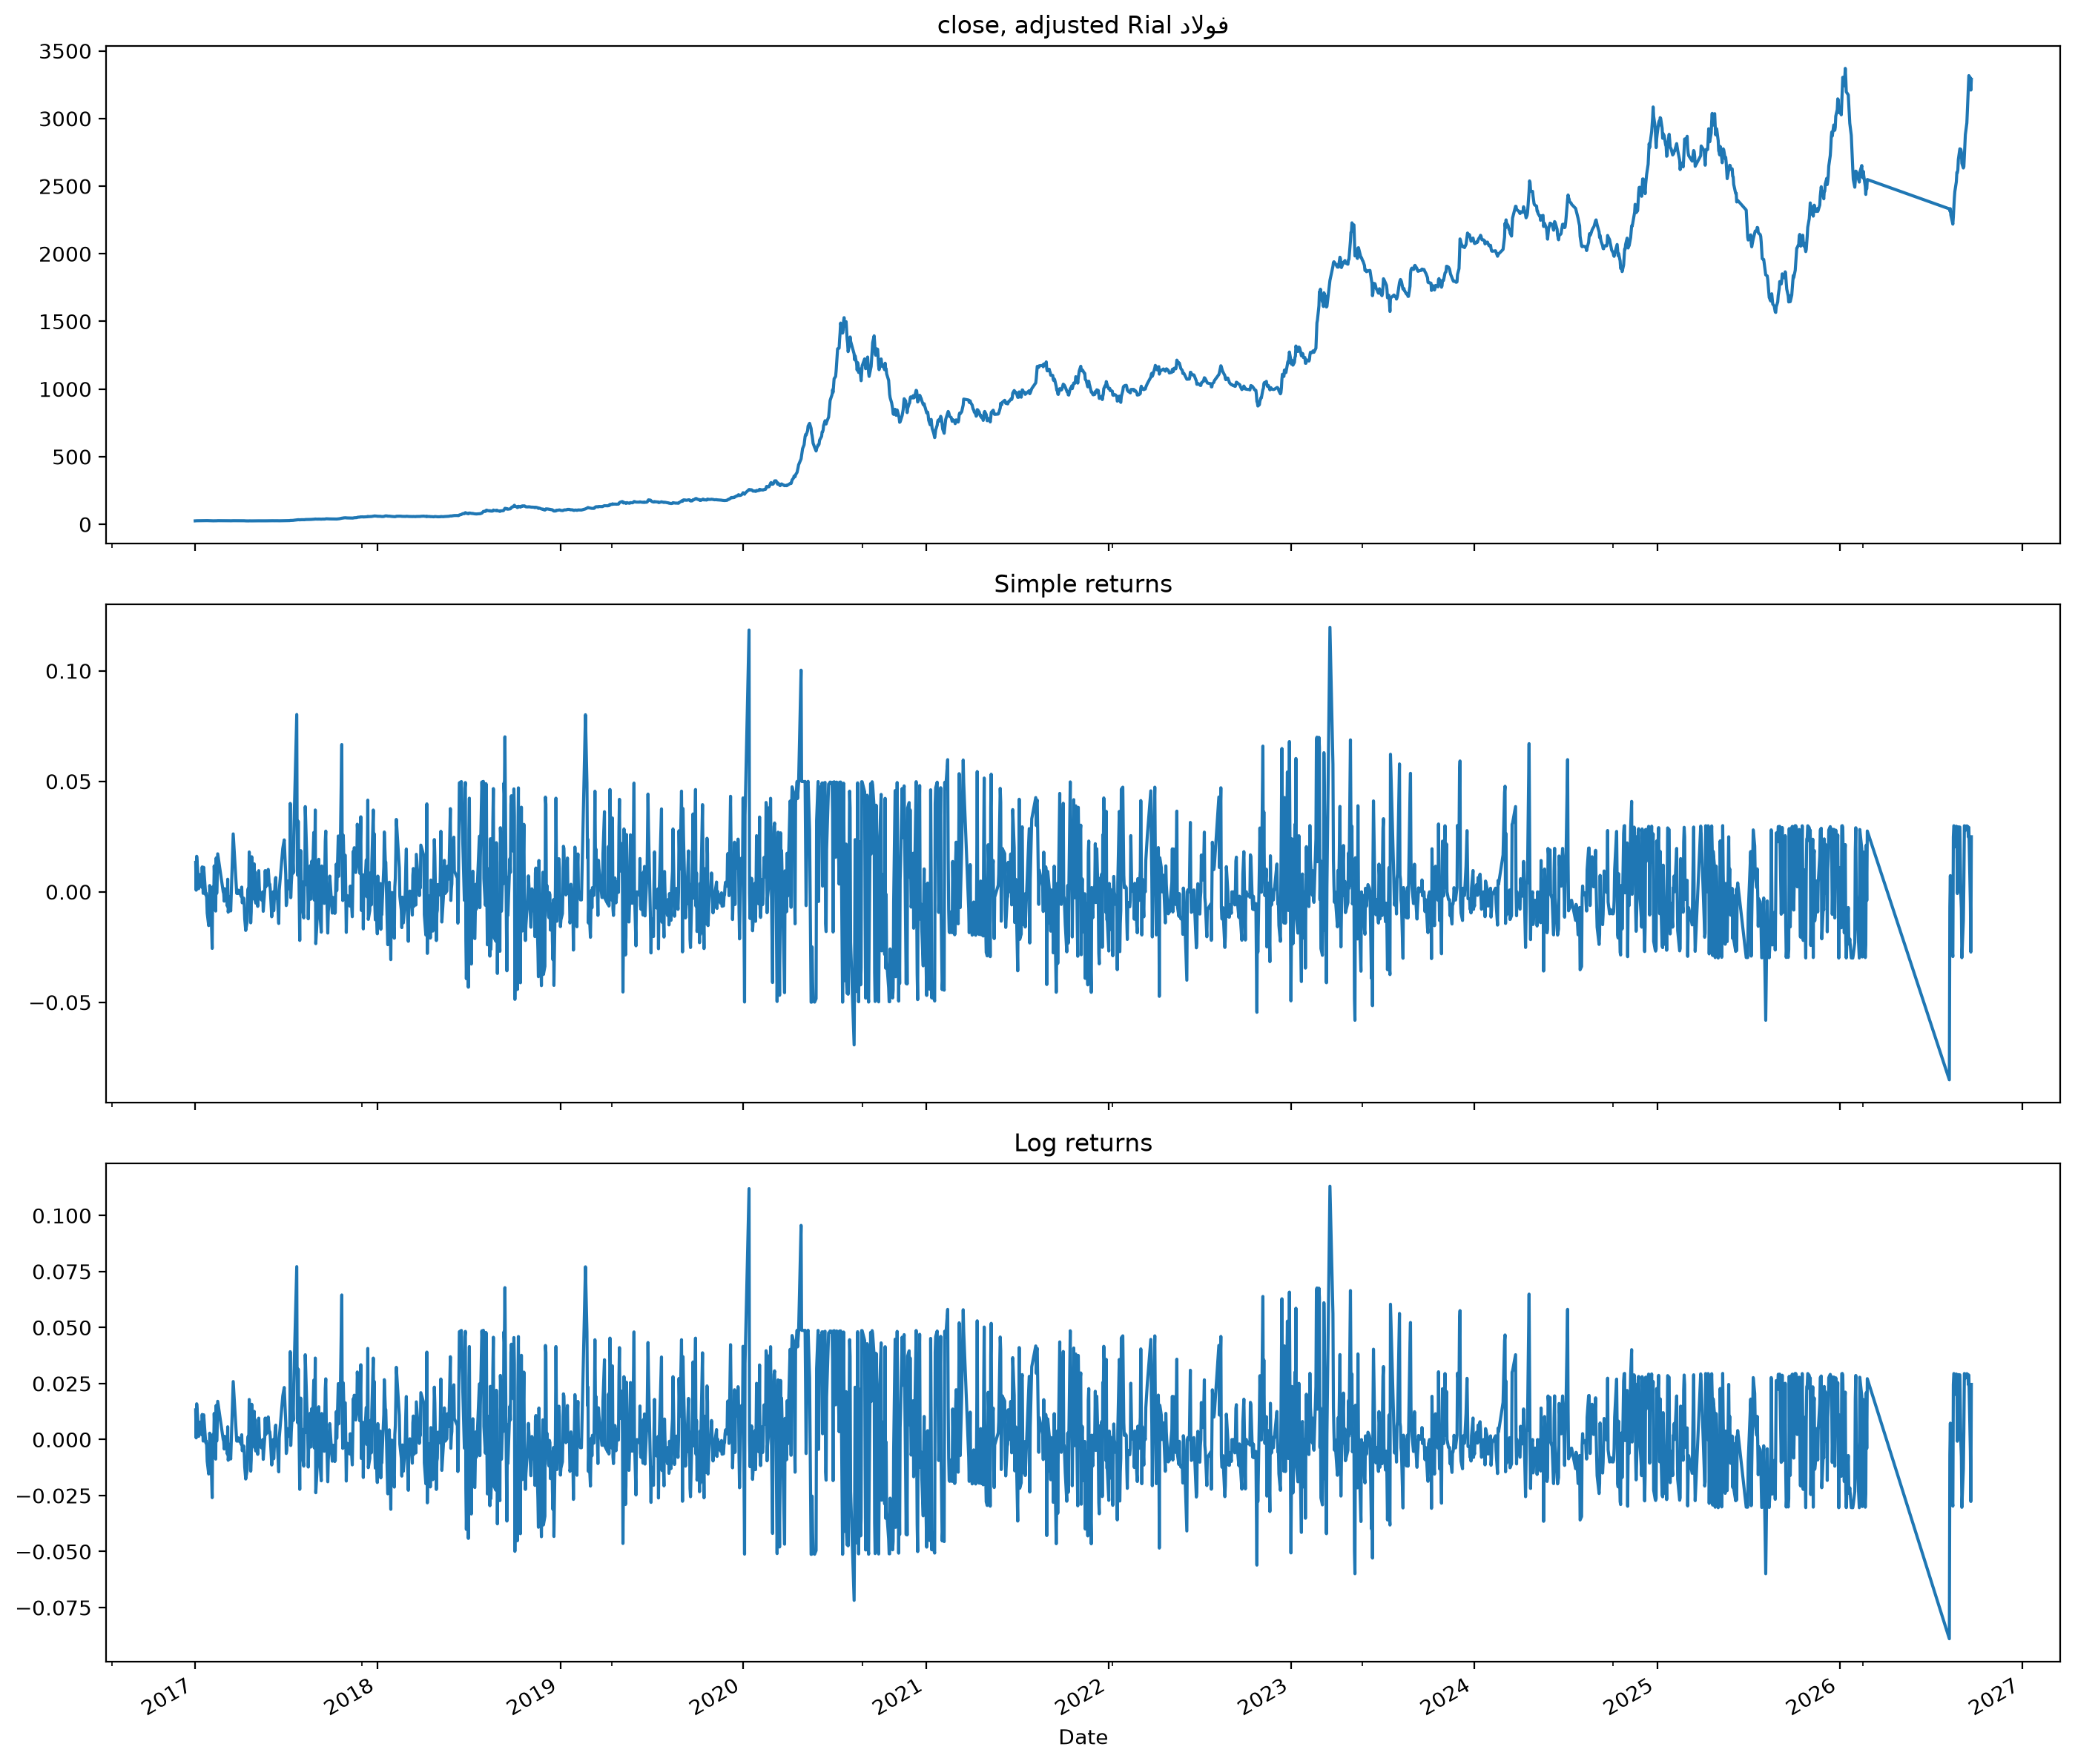

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
df["Close"].plot(ax=ax[0], title="فولاد close, adjusted Rial")
rtn["simple_rtn"].plot(ax=ax[1], title="Simple returns")
rtn["log_rtn"].plot(ax=ax[2], title="Log returns")
plt.tight_layout()
plt.show()

## 1.5 Identifying outliers

The 3σ rule on a 21-session rolling window, as in the book.

11 outliers


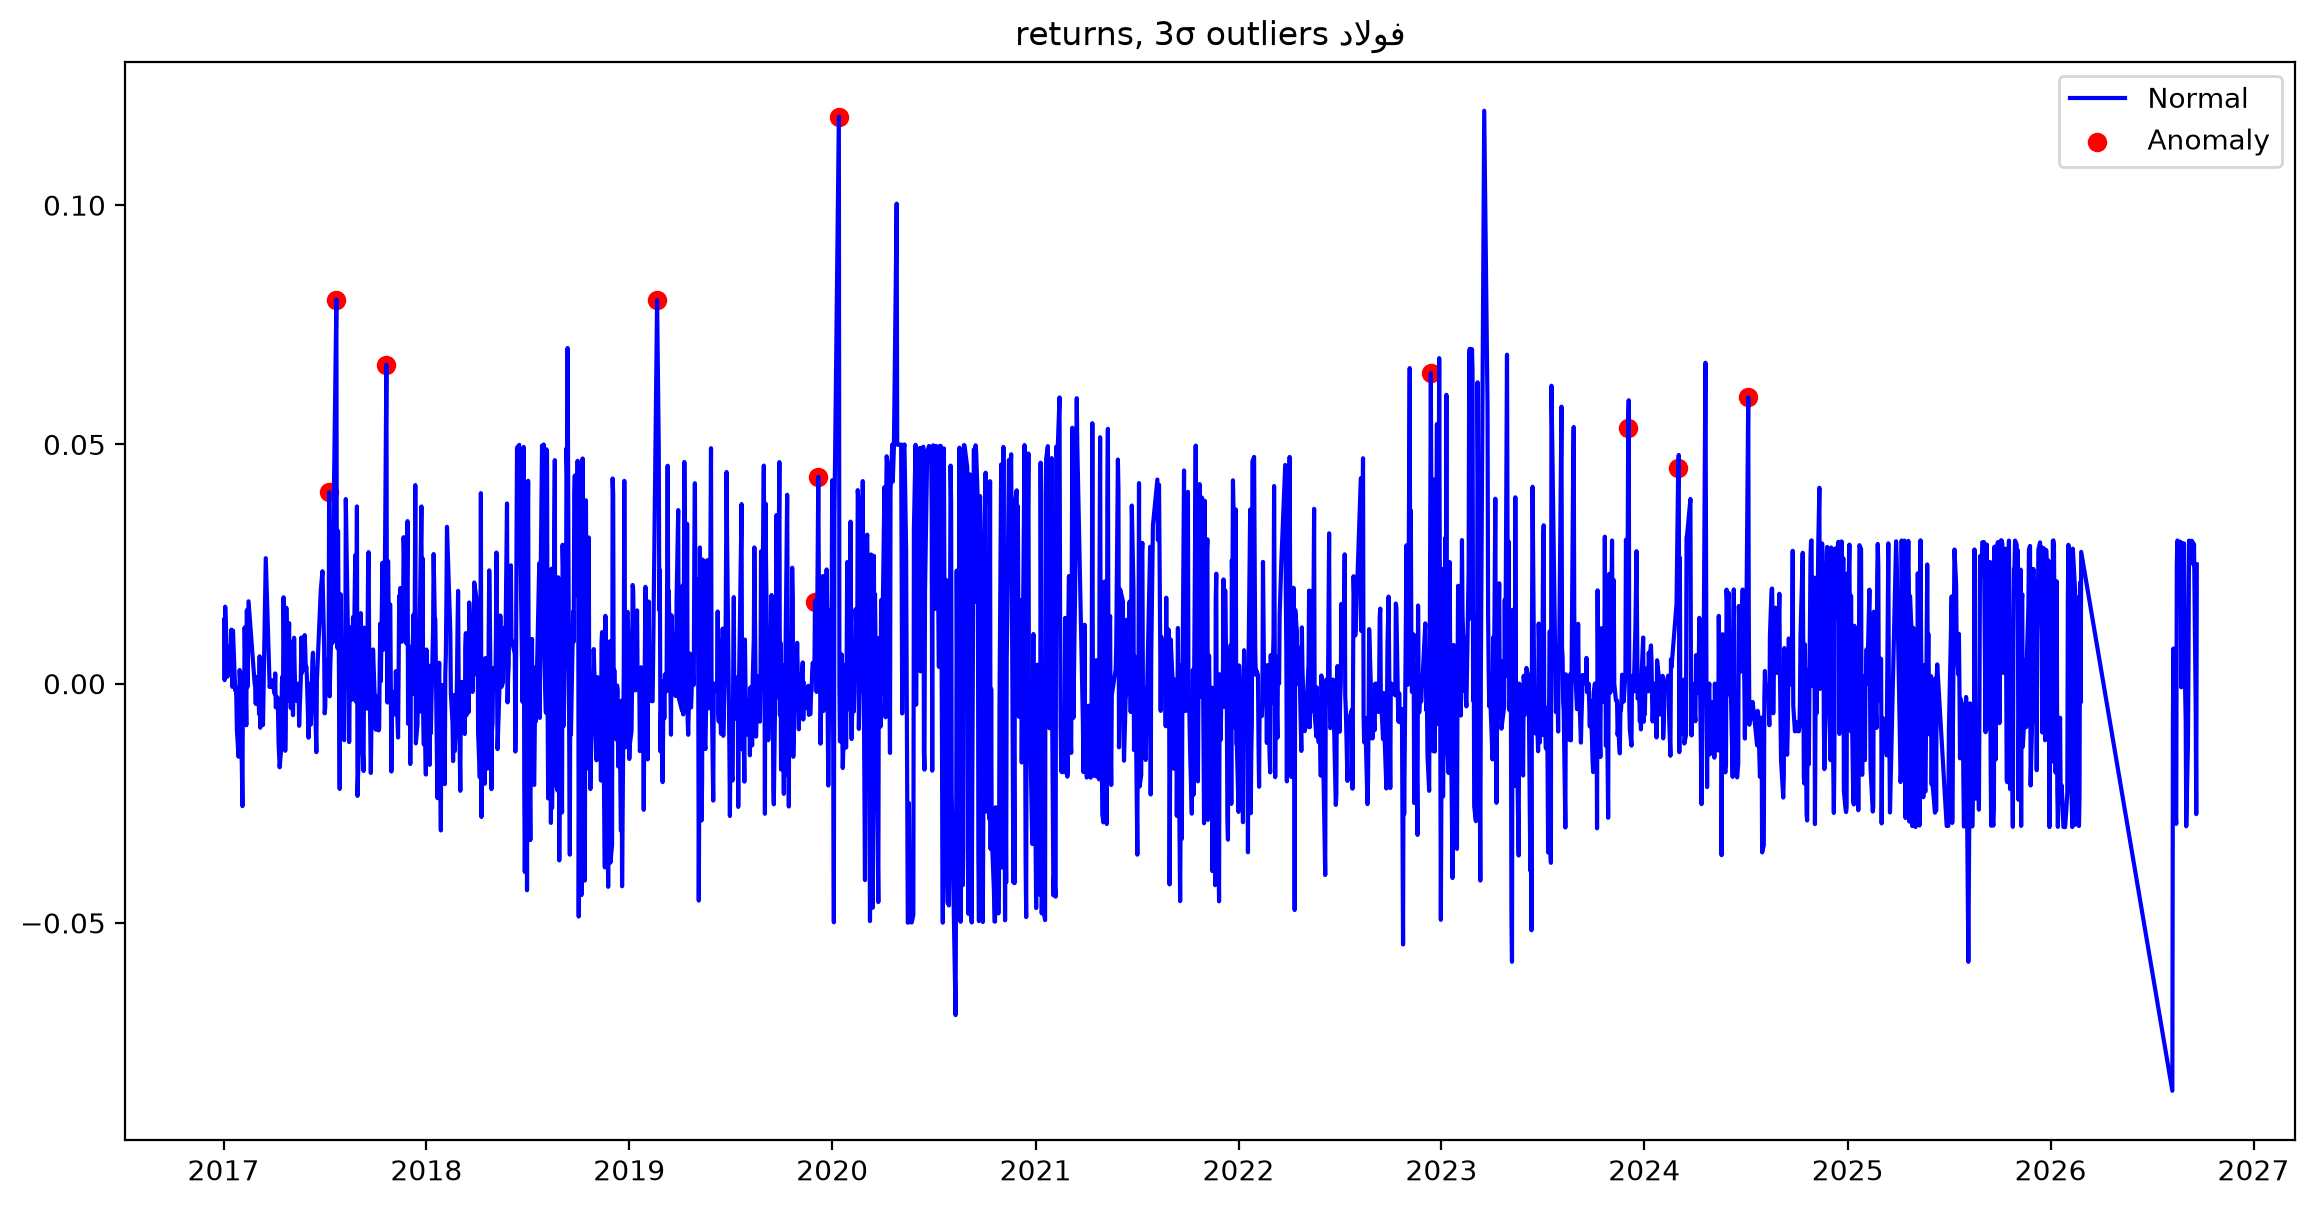

In [10]:
roll = rtn[["simple_rtn"]].rolling(window=21).agg(["mean", "std"])
roll.columns = roll.columns.droplevel()
out = rtn.join(roll)

def is_outlier(row, n_sigmas=3):
    x, mu, sigma = row["simple_rtn"], row["mean"], row["std"]
    return 1 if (x > mu + n_sigmas * sigma) or (x < mu - n_sigmas * sigma) else 0

out["outlier"] = out.apply(is_outlier, axis=1)
outliers = out.loc[out["outlier"] == 1, ["simple_rtn"]]
print(len(outliers), "outliers")

fig, ax = plt.subplots()
ax.plot(out.index, out["simple_rtn"], color="blue", label="Normal")
ax.scatter(outliers.index, outliers["simple_rtn"], color="red", label="Anomaly")
ax.set_title("فولاد returns, 3σ outliers")
ax.legend()
plt.show()

## 1.6 Stylised facts of asset returns

### Fact 1: non-Gaussian distribution

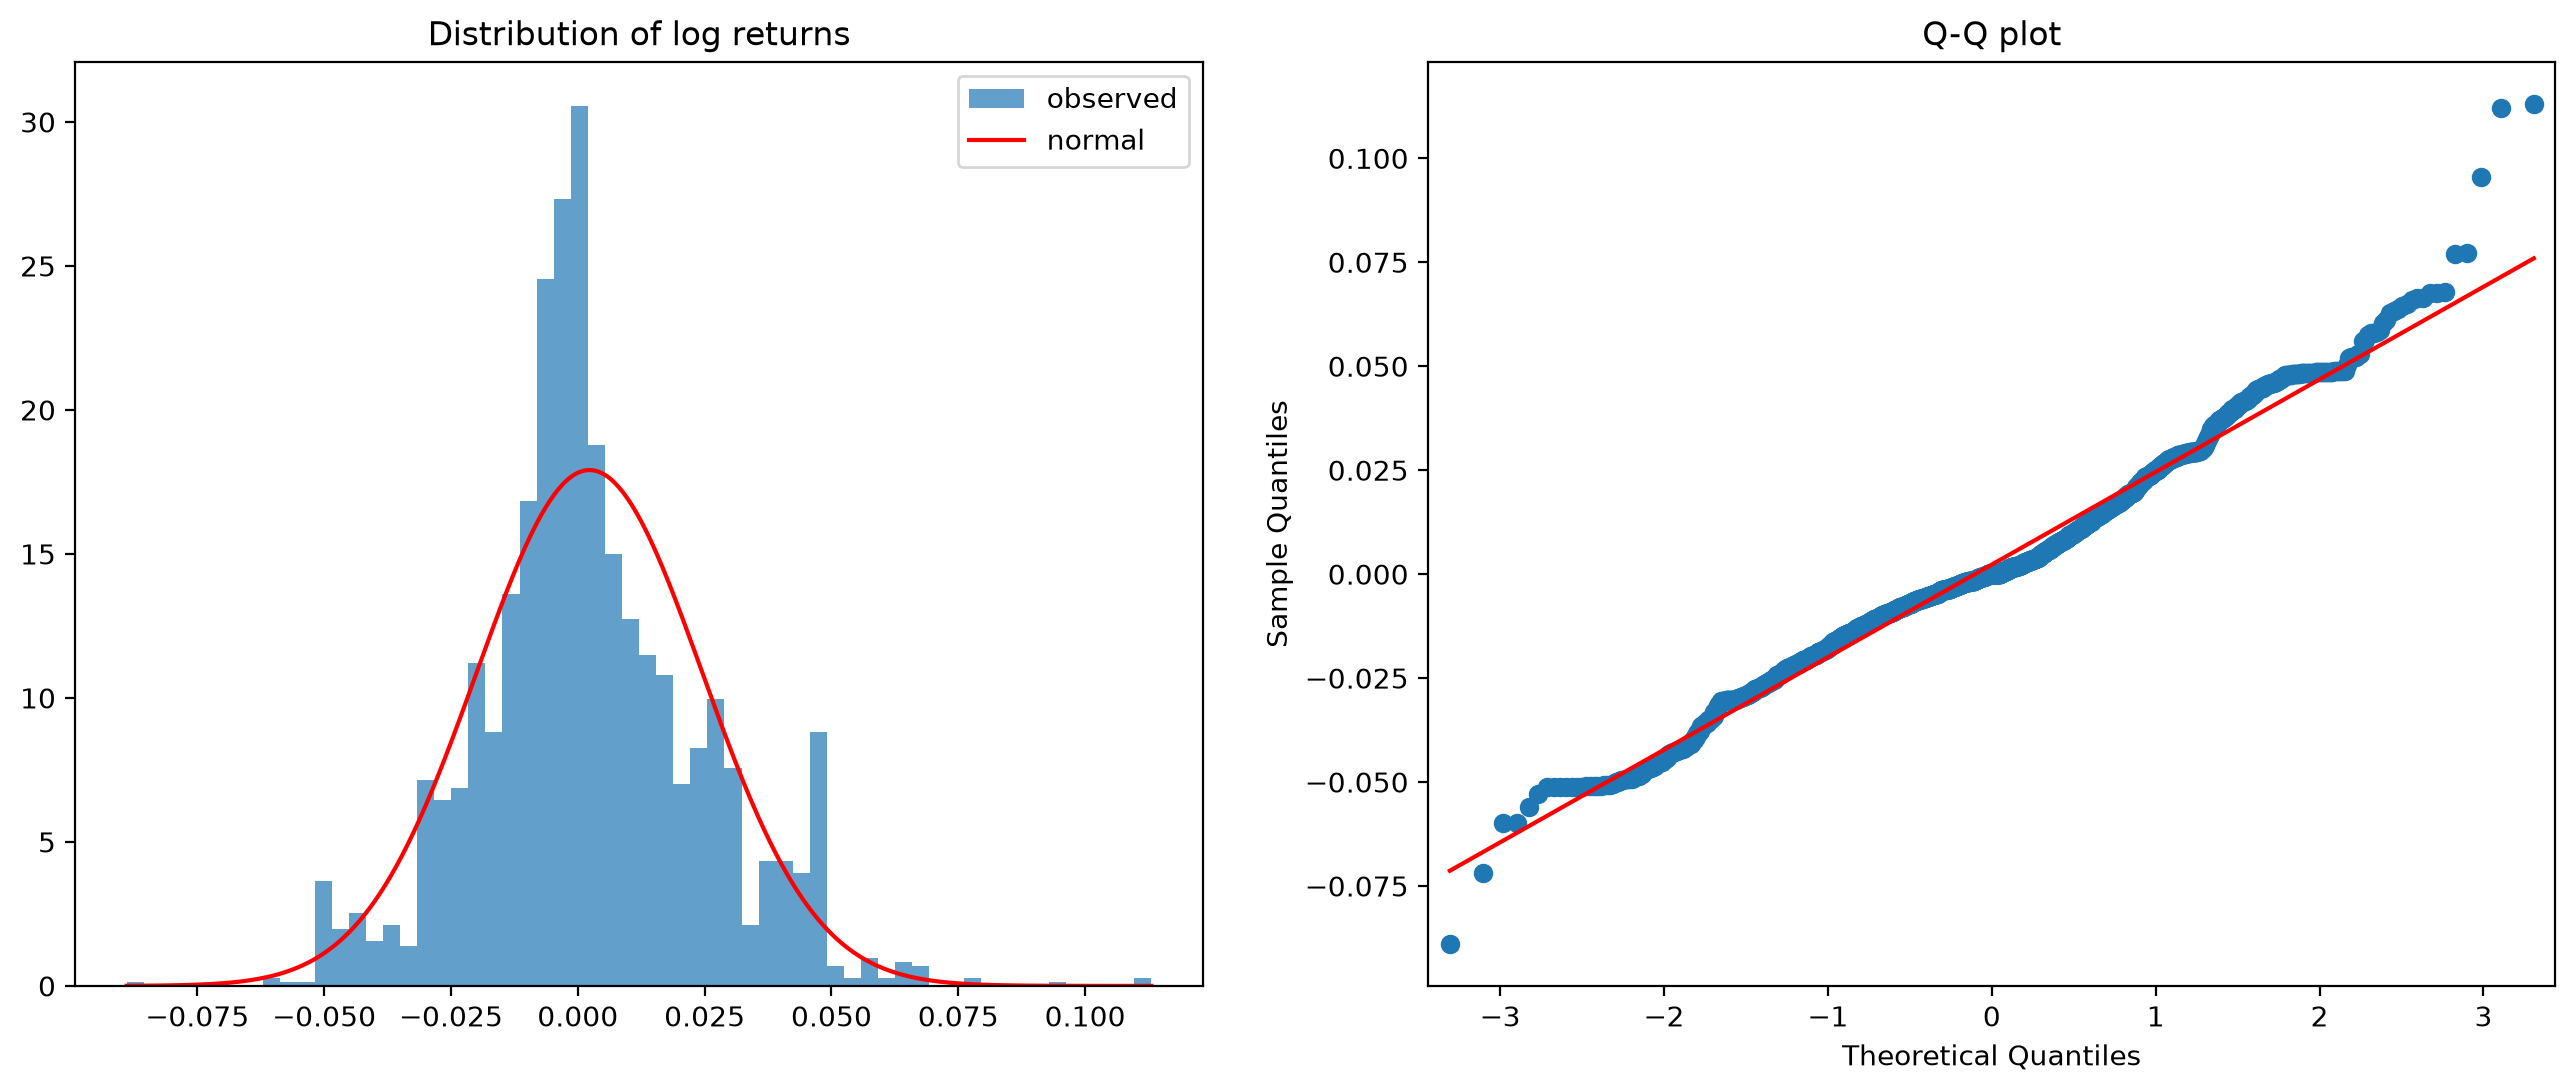

skew 0.33, kurtosis 0.95
Jarque-Bera p-value: 1.859170005165771e-26


In [11]:
r = rtn["log_rtn"]
mu, sigma = r.mean(), r.std()
x = np.linspace(r.min(), r.max(), 500)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].hist(r, bins=60, density=True, alpha=0.7, label="observed")
ax[0].plot(x, scs.norm.pdf(x, mu, sigma), "r", label="normal")
ax[0].set_title("Distribution of log returns")
ax[0].legend()
sm.qqplot(r.values, line="s", ax=ax[1])
ax[1].set_title("Q-Q plot")
plt.show()

print(f"skew {scs.skew(r):.2f}, kurtosis {scs.kurtosis(r):.2f}")
print("Jarque-Bera p-value:", scs.jarque_bera(r)[1])

### Fact 2: volatility clustering

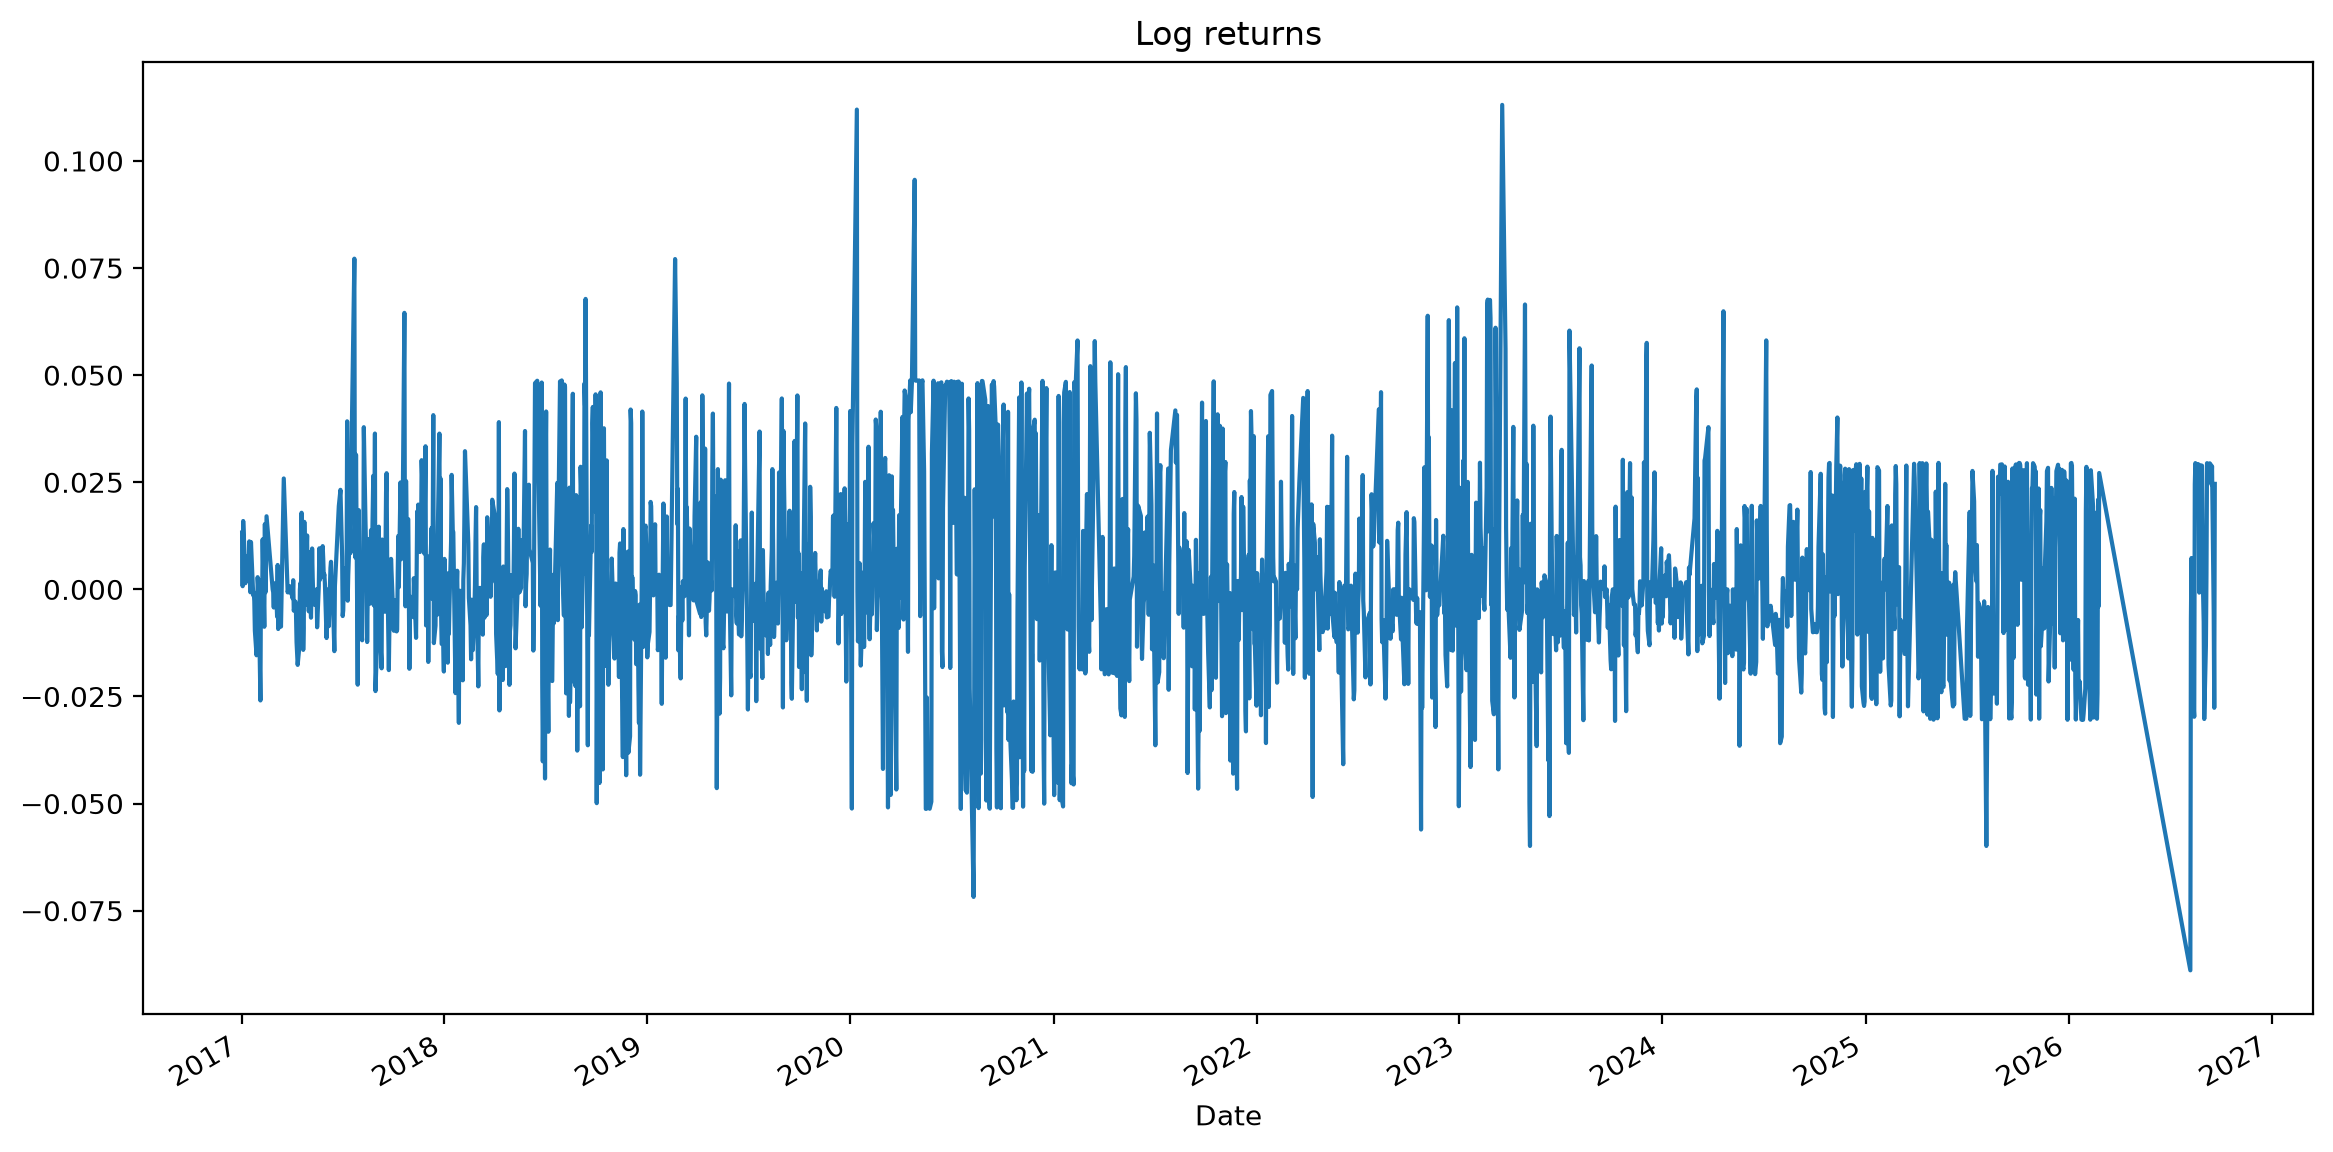

In [12]:
r.plot(title="Log returns")
plt.show()

### Fact 3: no autocorrelation in returns

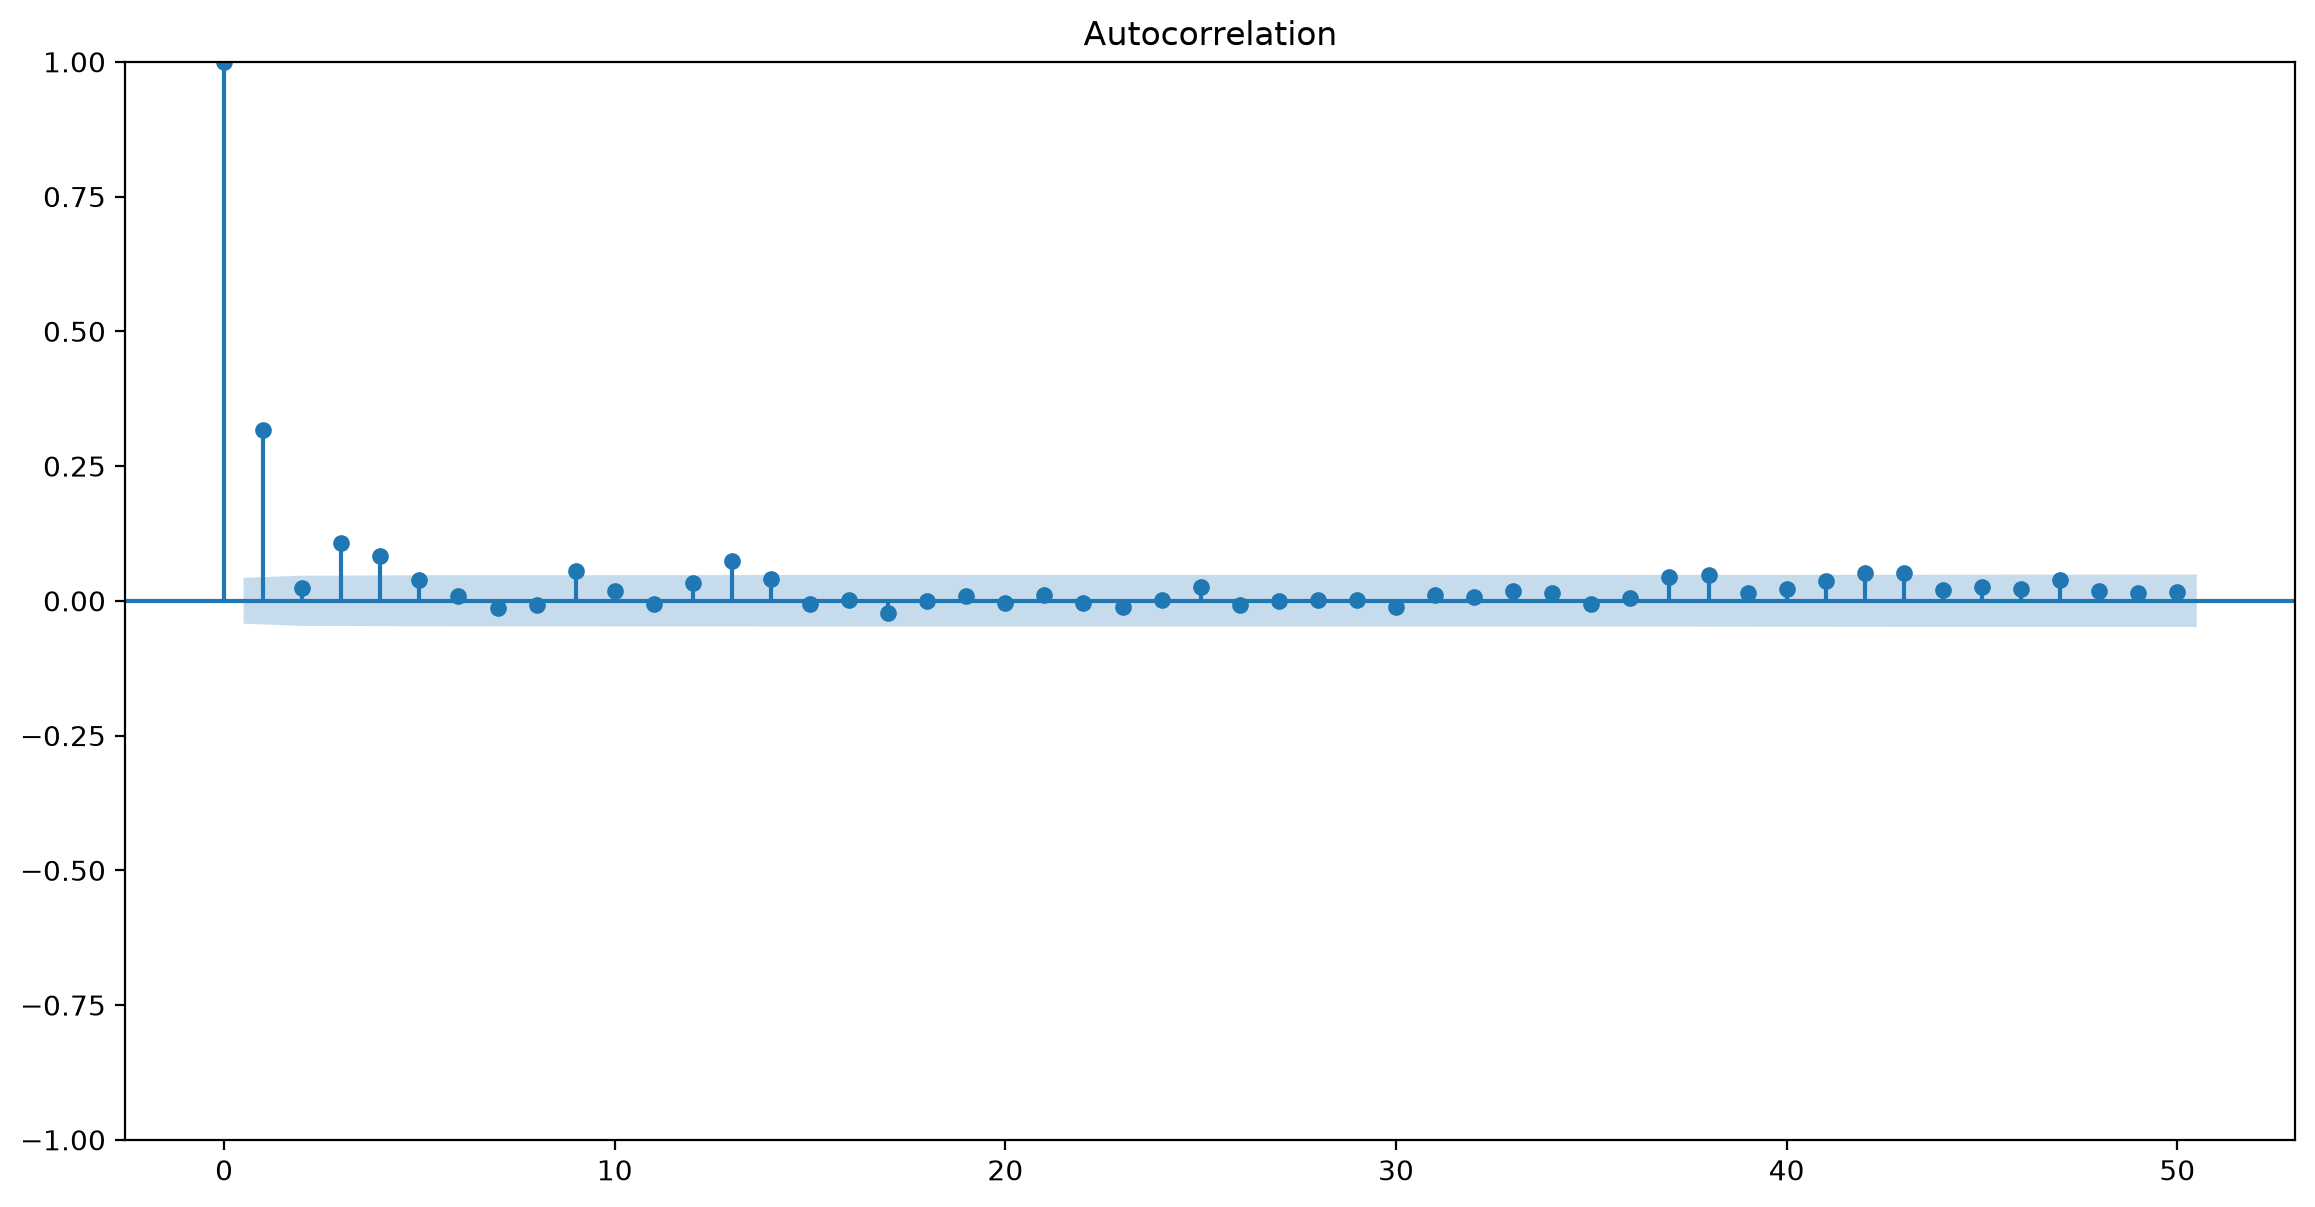

In [13]:
smt.graphics.plot_acf(r, lags=50, alpha=0.05)
plt.show()

### Fact 4: small, slowly decaying autocorrelation in squared and absolute returns

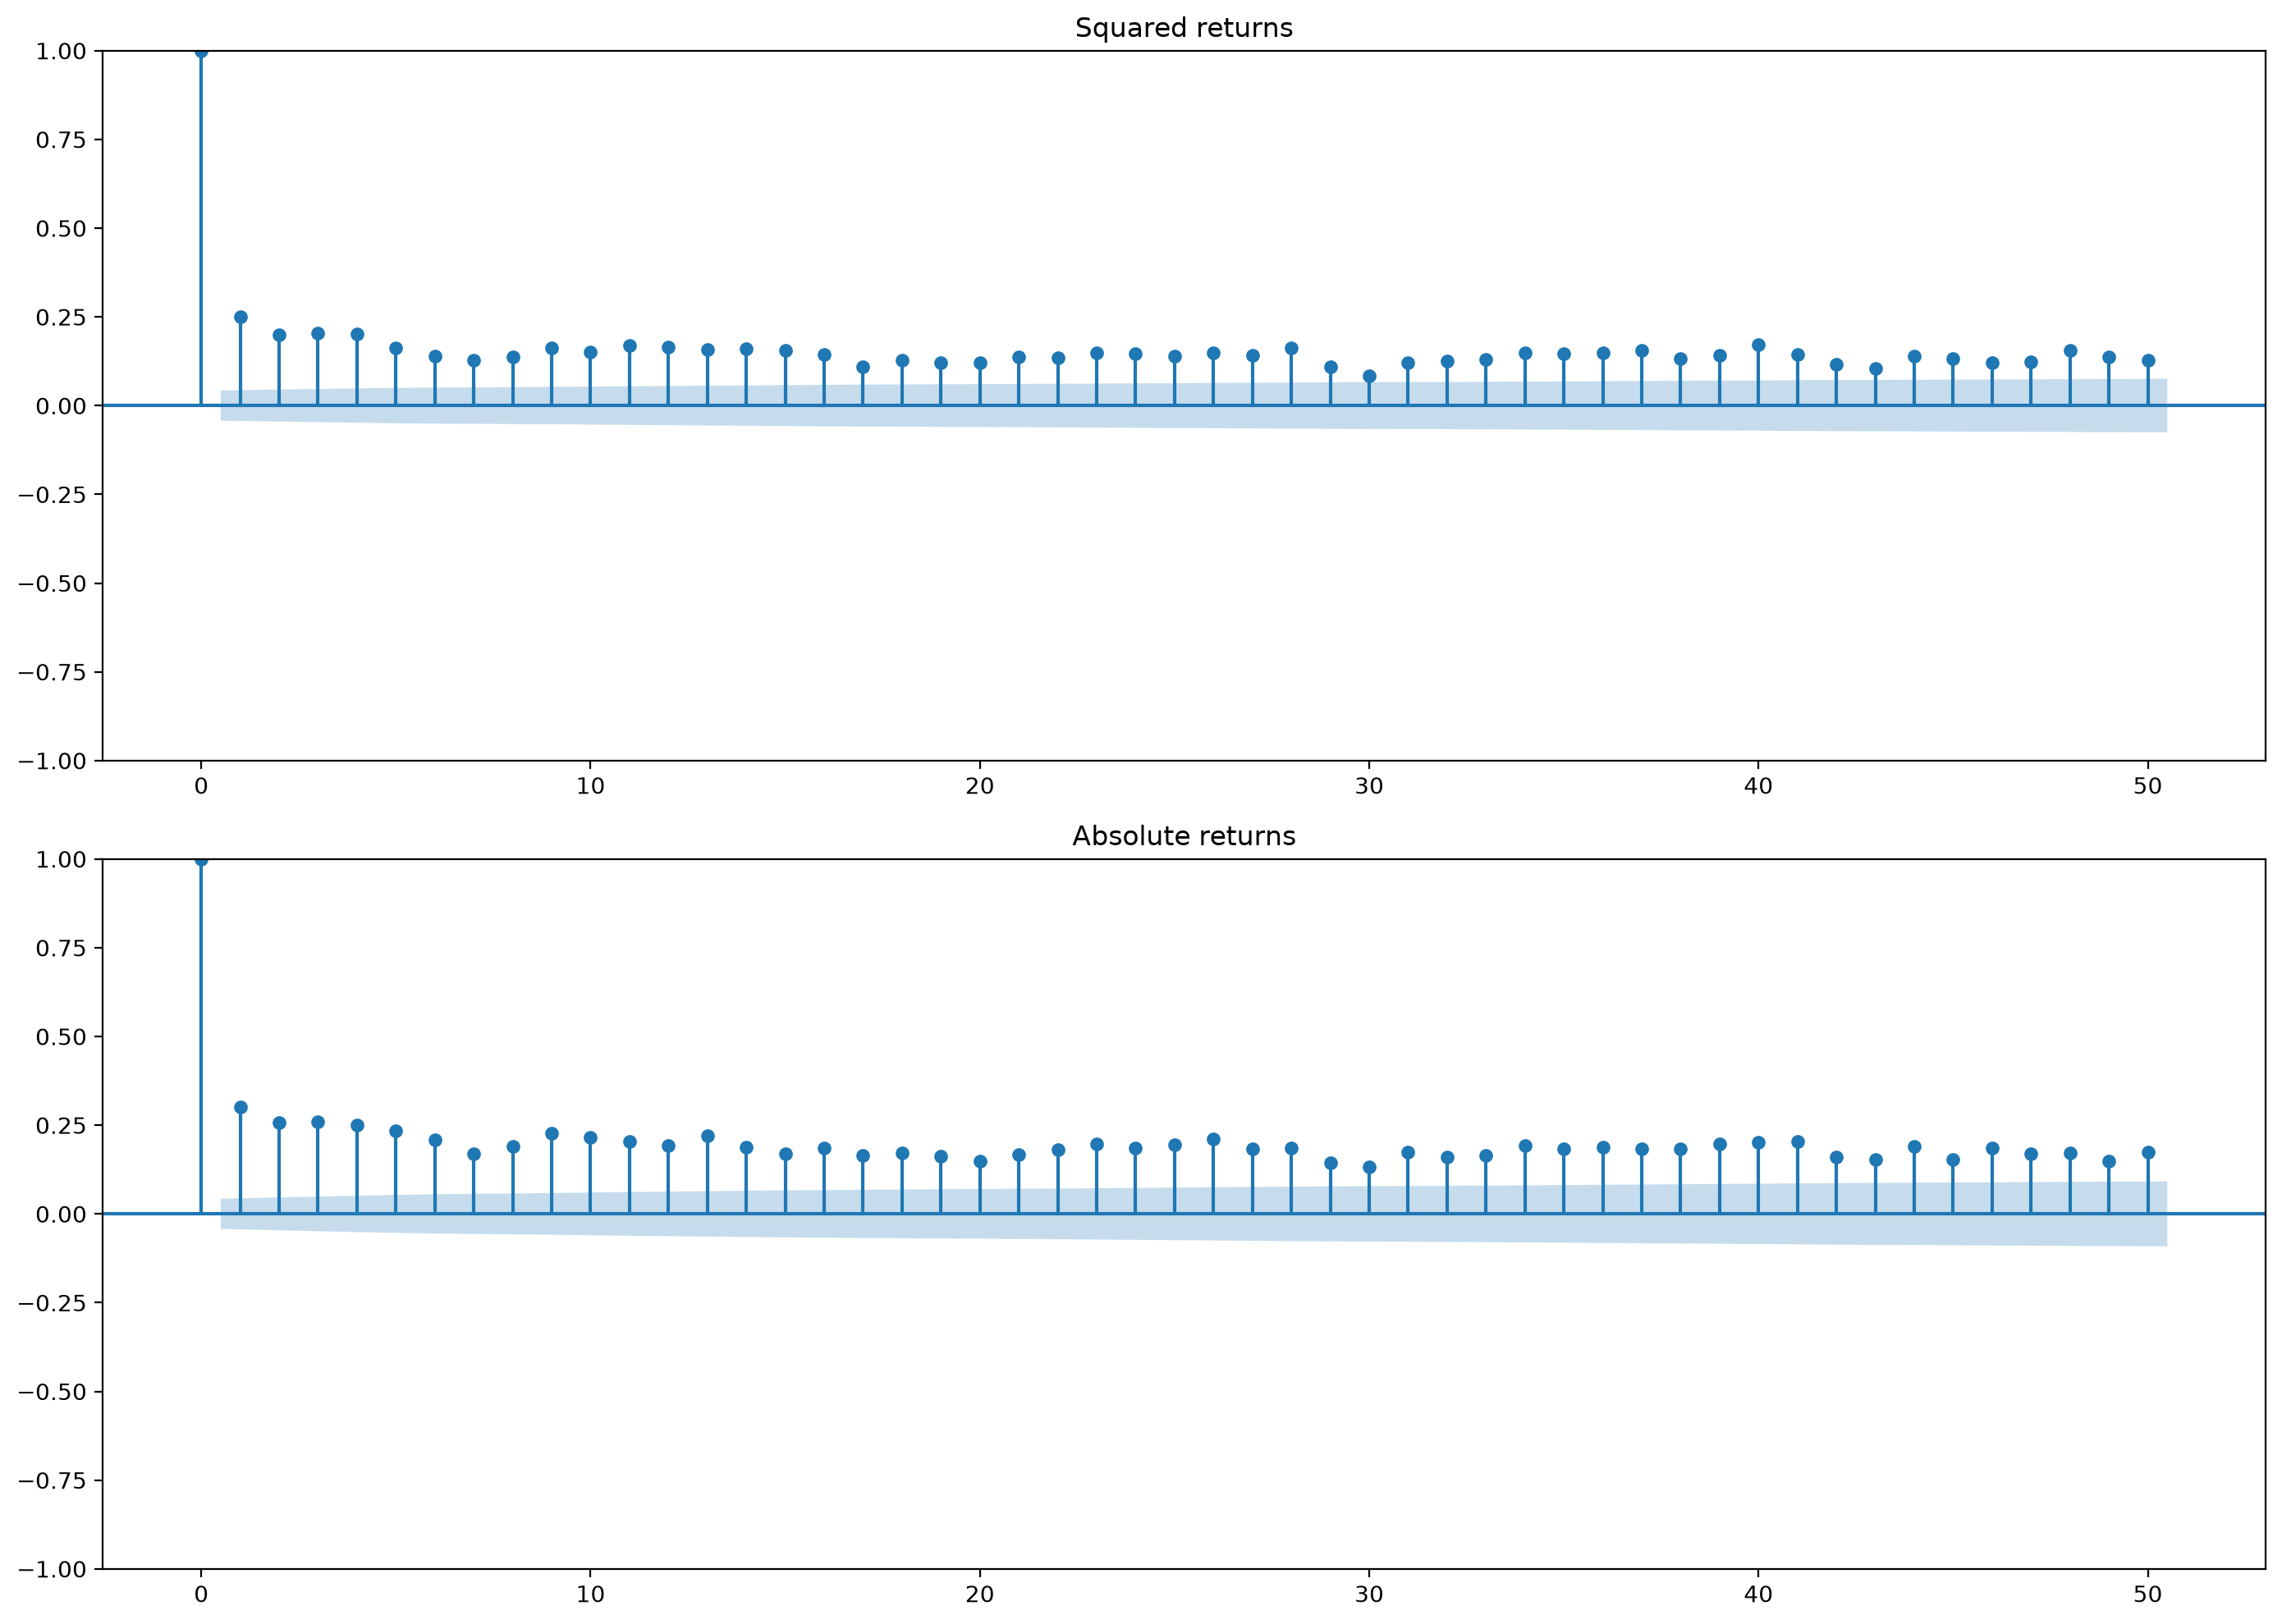

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
smt.graphics.plot_acf(r ** 2, lags=50, alpha=0.05, ax=ax[0])
ax[0].set_title("Squared returns")
smt.graphics.plot_acf(np.abs(r), lags=50, alpha=0.05, ax=ax[1])
ax[1].set_title("Absolute returns")
plt.tight_layout()
plt.show()

### Fact 5: leverage effect

The book compares returns with a 252-day rolling volatility; here it is the measured
session count. A negative correlation between returns and later volatility is the
leverage effect; the correlation printed below says whether this stock shows one.

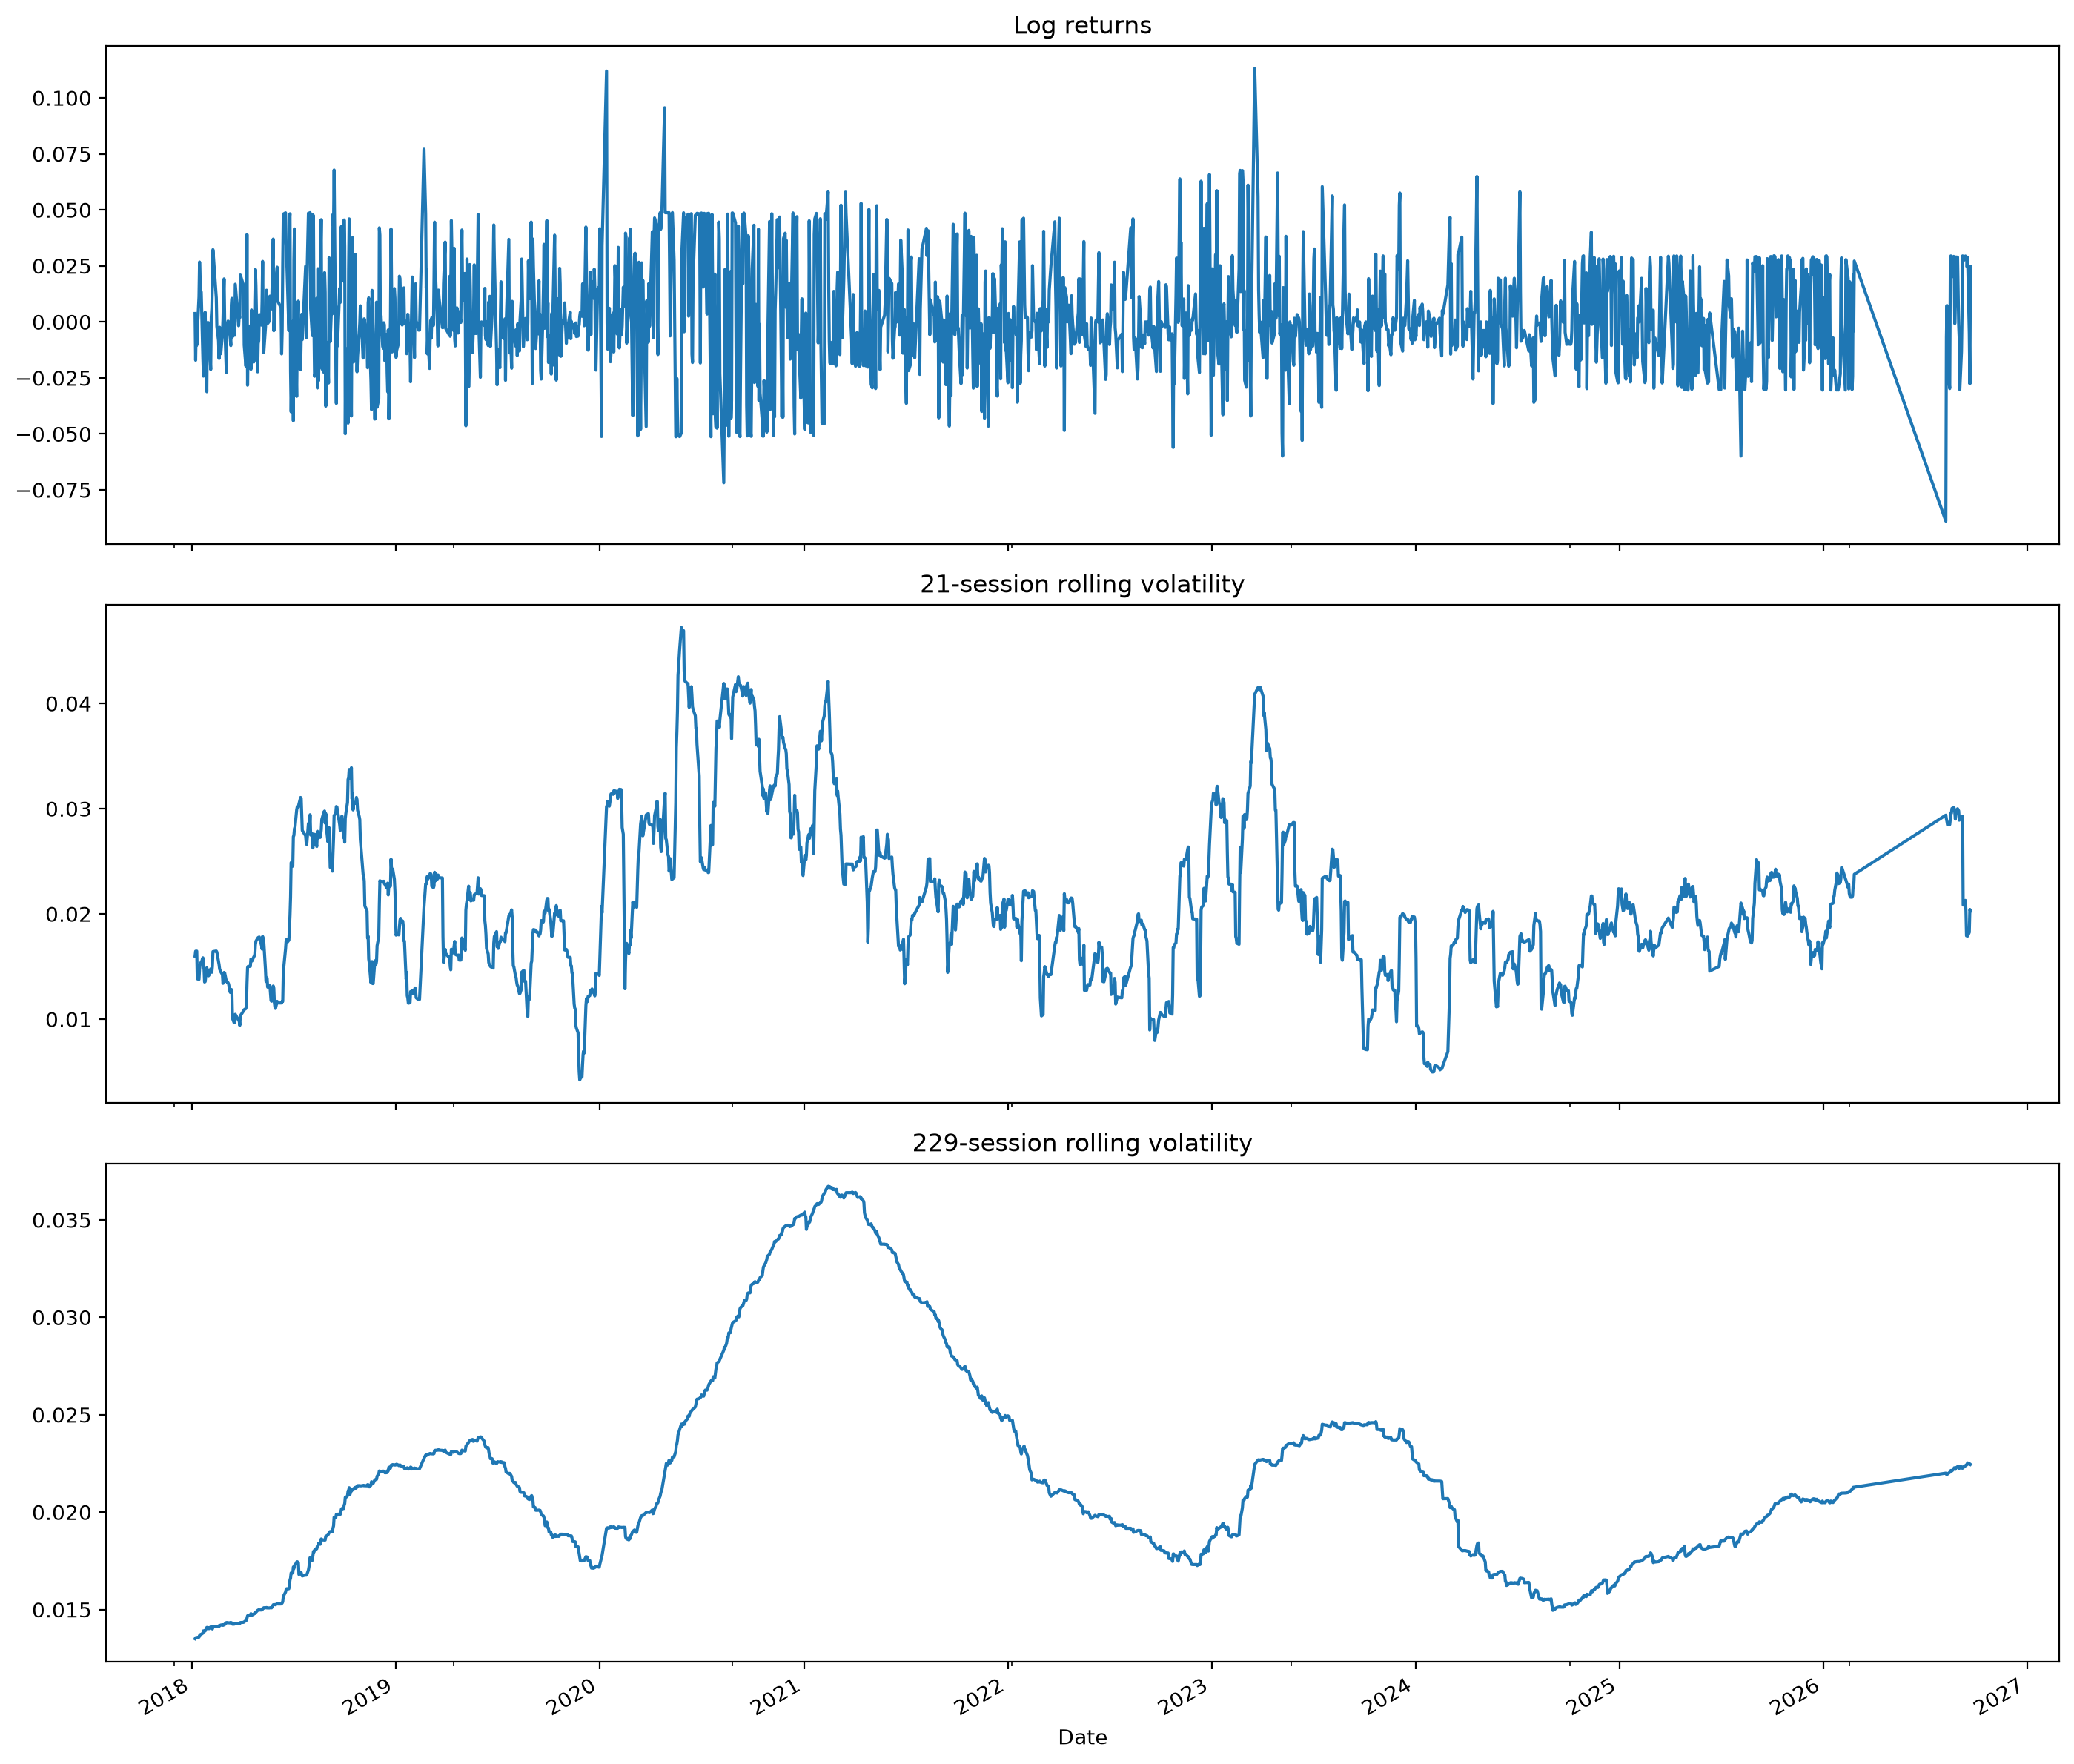

corr(return, next-day 21d vol): 0.048


In [15]:
vol = pd.DataFrame({"rtn": r, "vol_21": r.rolling(21).std(), "vol_year": r.rolling(N_DAYS).std()}).dropna()
fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
vol["rtn"].plot(ax=ax[0], title="Log returns")
vol["vol_21"].plot(ax=ax[1], title="21-session rolling volatility")
vol["vol_year"].plot(ax=ax[2], title=f"{N_DAYS}-session rolling volatility")
plt.tight_layout()
plt.show()
print("corr(return, next-day 21d vol):", vol["rtn"].corr(vol["vol_21"].shift(-1)).round(3))

# Chapter 2: Technical analysis

## 2.1 Candlestick chart

The book uses cufflinks/plotly. A matplotlib version keeps the notebook free of a second
plotting stack: green when the close is above the open, red otherwise, volume beneath.

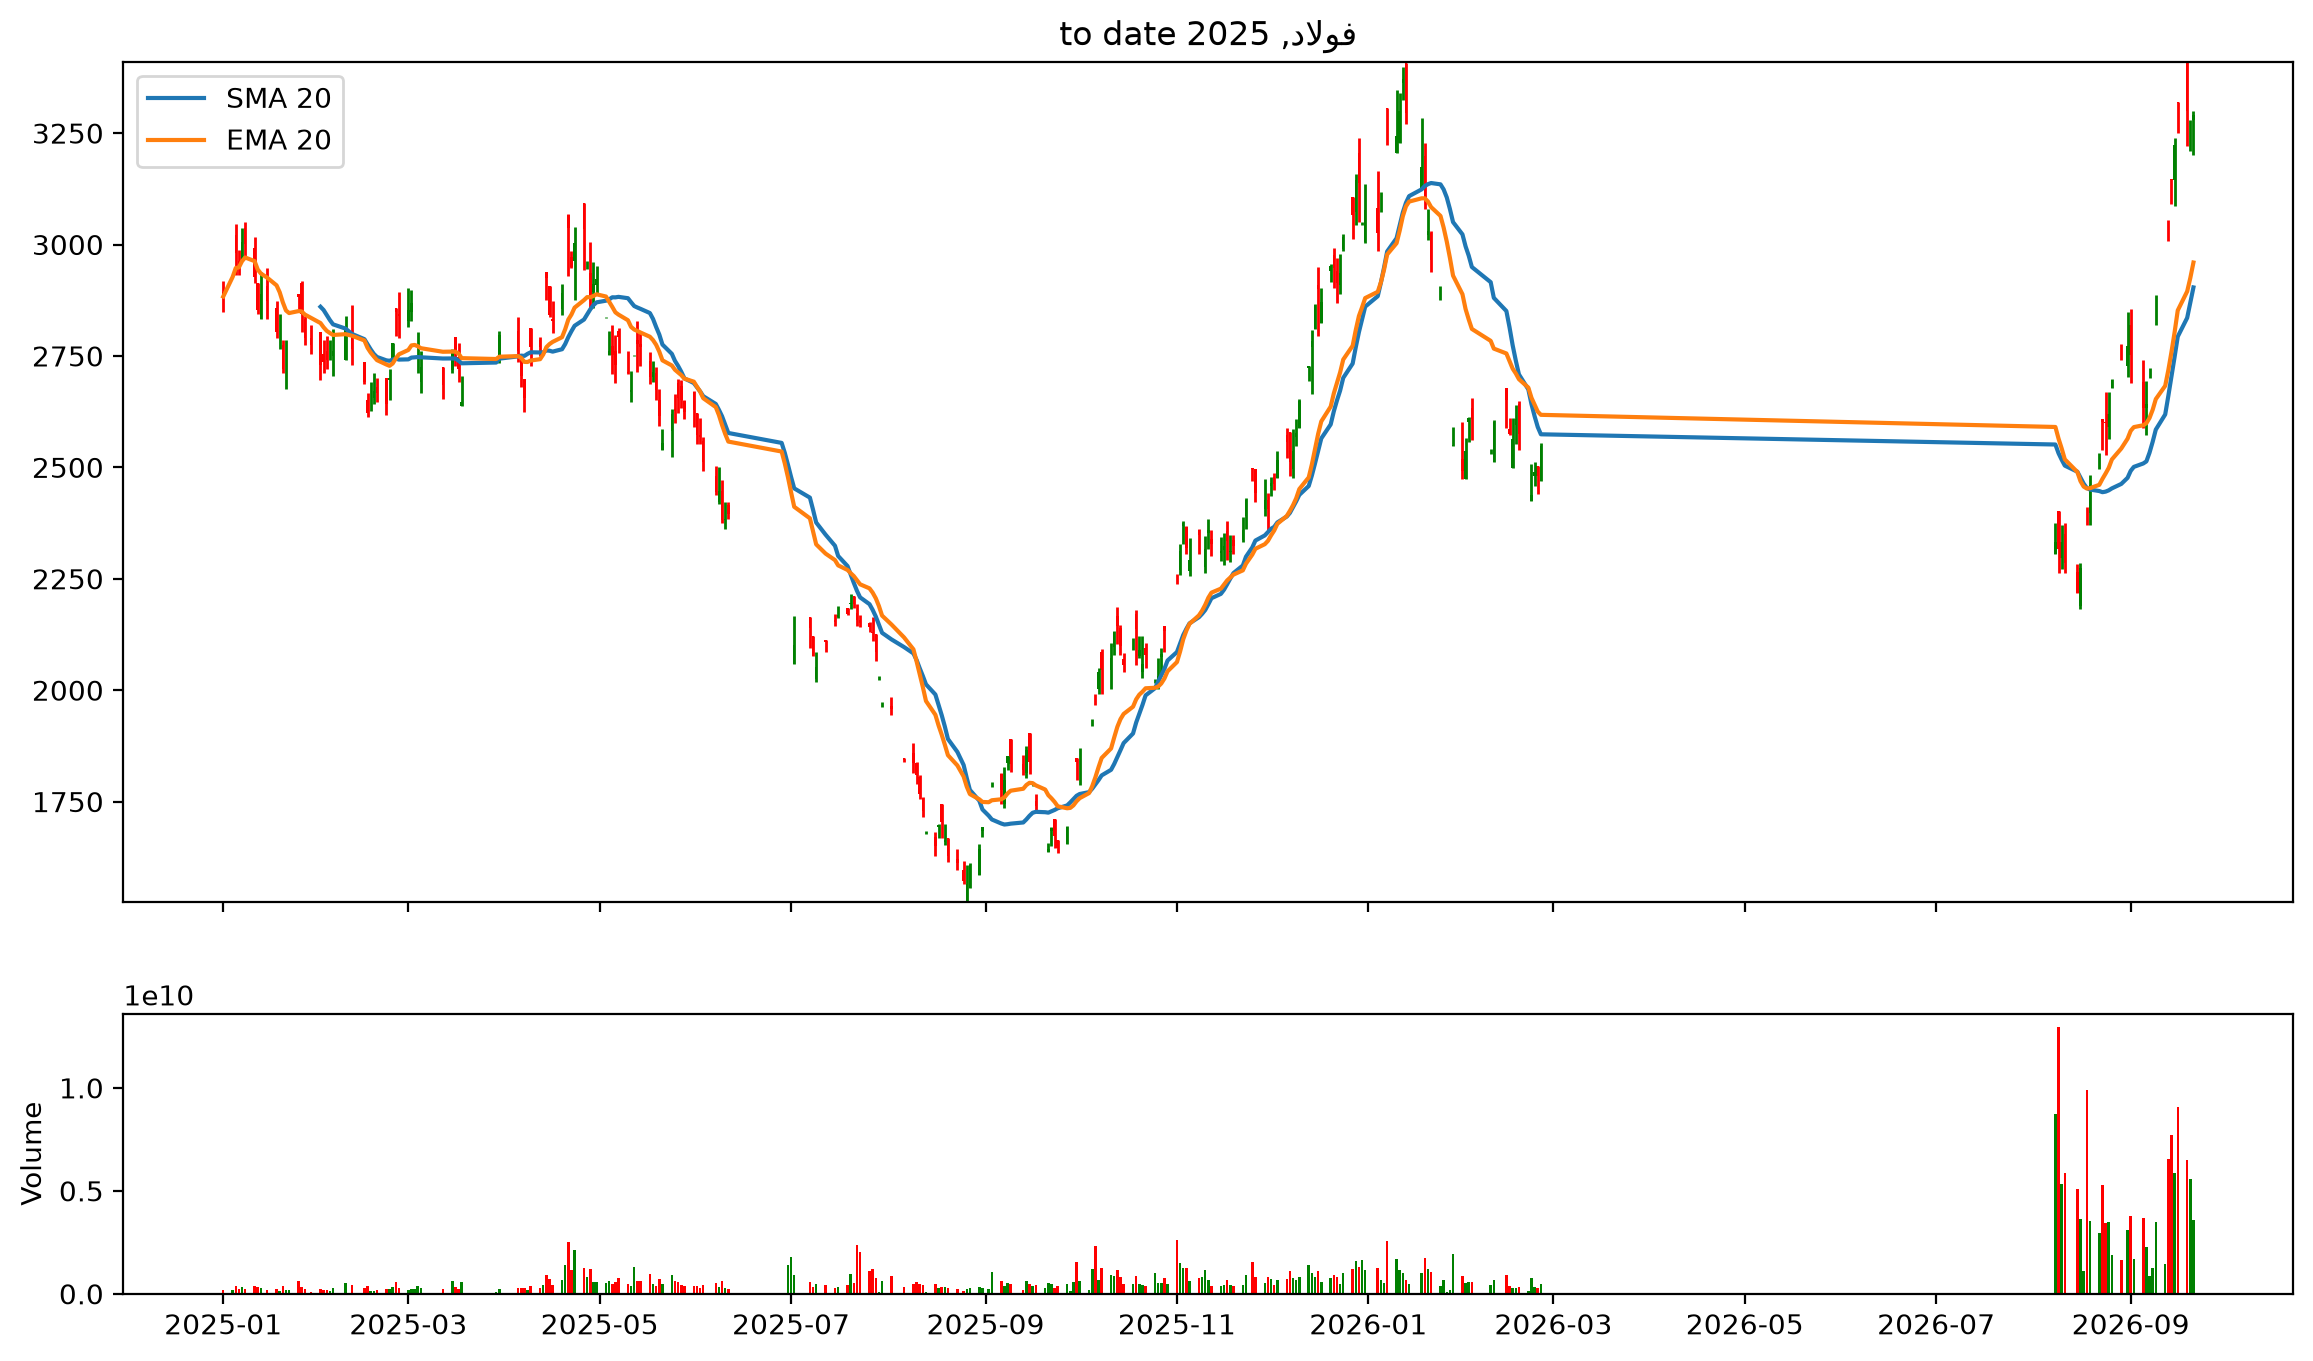

In [16]:
def candlestick(frame, title):
    fig, (ax, axv) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    up = frame["Close"] >= frame["Open"]
    colors = np.where(up, "green", "red")
    ax.vlines(frame.index, frame["Low"], frame["High"], color=colors, linewidth=1)
    ax.bar(frame.index, frame["Close"] - frame["Open"], bottom=frame["Open"], color=colors, width=0.8)
    ax.plot(frame.index, frame["Close"].rolling(20).mean(), color="tab:blue", label="SMA 20")
    ax.plot(frame.index, frame["Close"].ewm(span=20).mean(), color="tab:orange", label="EMA 20")
    ax.legend()
    ax.set_title(title)
    axv.bar(frame.index, frame["Volume"], color=colors, width=0.8)
    axv.set_ylabel("Volume")
    plt.show()

candlestick(df.loc["2025-01-01":], "فولاد, 2025 to date")

## 2.2 Backtesting a simple moving average strategy

Same `backtrader` code shape as the book: buy when the close crosses above its
20-session SMA, sell when it crosses below, all-in each time. TSETMC's `Close` is the
volume-weighted daily closing price; `Last` is the last trade. backtrader takes the
five OHLCV columns and ignores the rest.

SMA(20): 1,120,967,651 Rial | buy and hold: 14,076,818,106 Rial


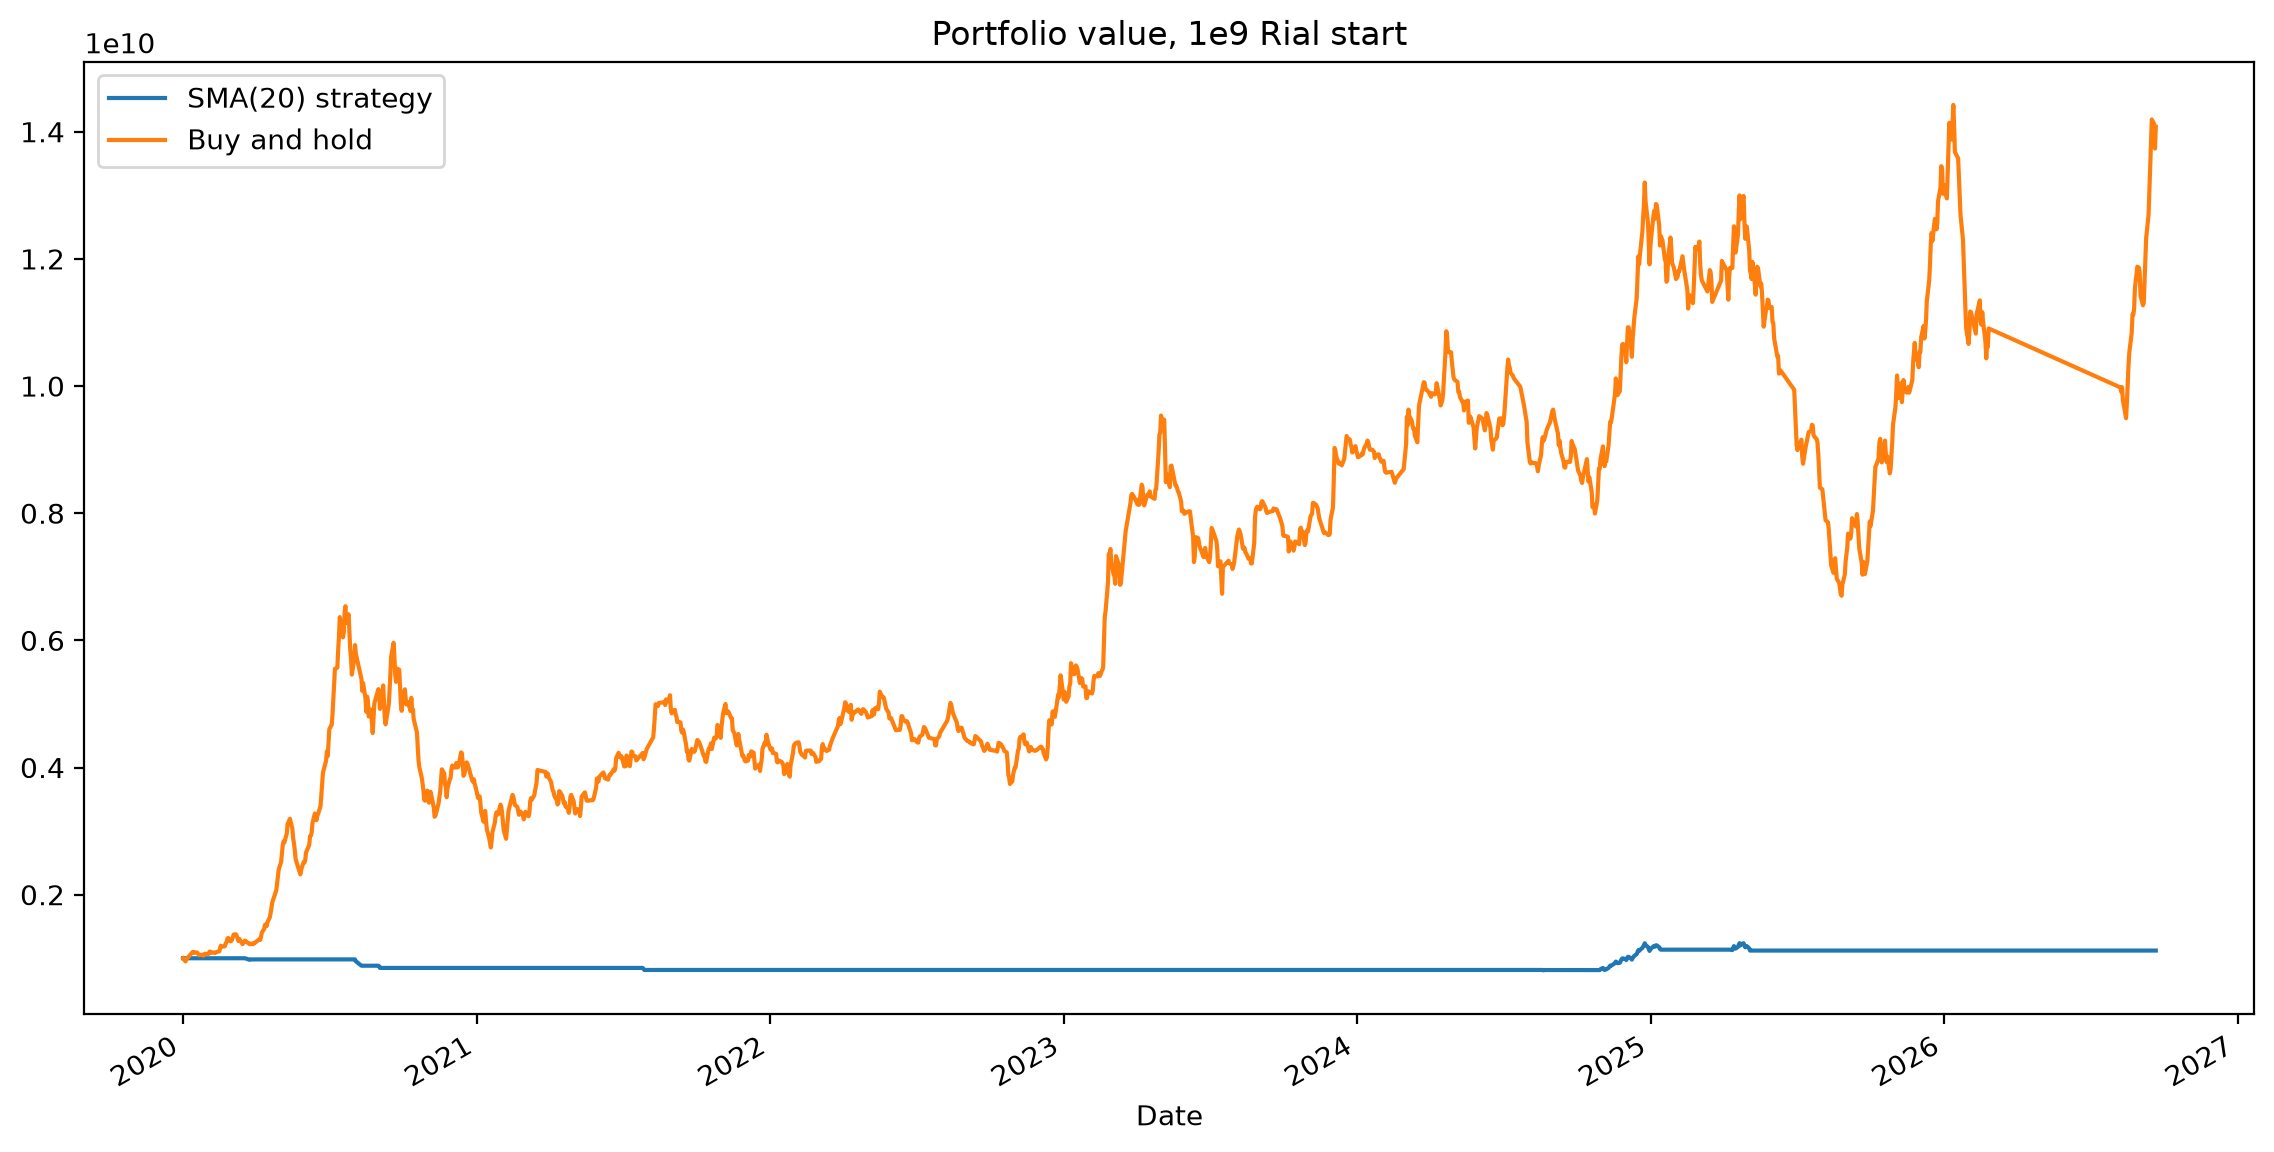

In [17]:
class SmaSignal(bt.Strategy):
    params = (("period", 20),)

    def __init__(self):
        self.signal = bt.ind.CrossOver(self.data.close, bt.ind.SMA(period=self.p.period))

    def next(self):
        if not self.position and self.signal > 0:
            size = int(self.broker.getcash() / self.data.open[0])
            self.buy(size=size)
        elif self.position and self.signal < 0:
            self.sell(size=self.position.size)


def run_backtest(strategy, frame, cash=1e9, **kwargs):
    """Returns (final_value, equity_curve) for a strategy on an OHLCV frame."""
    data = bt.feeds.PandasData(dataname=frame[["Open", "High", "Low", "Close", "Volume"]])
    cerebro = bt.Cerebro(stdstats=False)
    cerebro.adddata(data)
    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=0.0)
    cerebro.addstrategy(strategy, **kwargs)
    cerebro.addsizer(bt.sizers.PercentSizer, percents=95)
    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="returns", timeframe=bt.TimeFrame.Days)
    result = cerebro.run()[0]
    daily = pd.Series(result.analyzers.returns.get_analysis())
    daily.index = pd.to_datetime(daily.index)
    equity = cash * (1 + daily).cumprod()
    return cerebro.broker.getvalue(), equity


bt_df = df.loc["2020-01-01":]
final, sma_equity = run_backtest(SmaSignal, bt_df)
buy_hold = 1e9 * bt_df["Close"] / bt_df["Close"].iloc[0]
print(f"SMA(20): {final:,.0f} Rial | buy and hold: {buy_hold.iloc[-1]:,.0f} Rial")
ax = sma_equity.plot(label="SMA(20) strategy")
buy_hold.plot(ax=ax, label="Buy and hold")
ax.set_title("Portfolio value, 1e9 Rial start")
ax.legend()
plt.show()

### There's more: the SMA period

The book optimises the period with `cerebro.optstrategy`; a loop over
`run_backtest` reads better and prints the same table.

In [18]:
grid = {p: run_backtest(SmaSignal, bt_df, period=p)[0] for p in (10, 20, 30, 50, 100)}
pd.Series(grid, name="final value").map("{:,.0f}".format)

10       951,279,706
20     1,120,967,651
30     1,335,473,396
50     1,324,119,865
100    1,125,891,118
Name: final value, dtype: str

## 2.3 Bollinger Bands and a buy/sell strategy

Buy when the close crosses the lower band upward, sell when it crosses the upper band
downward. 20 sessions, 2 standard deviations, as in the book.

Bollinger(20, 2): 1,447,517,615 Rial


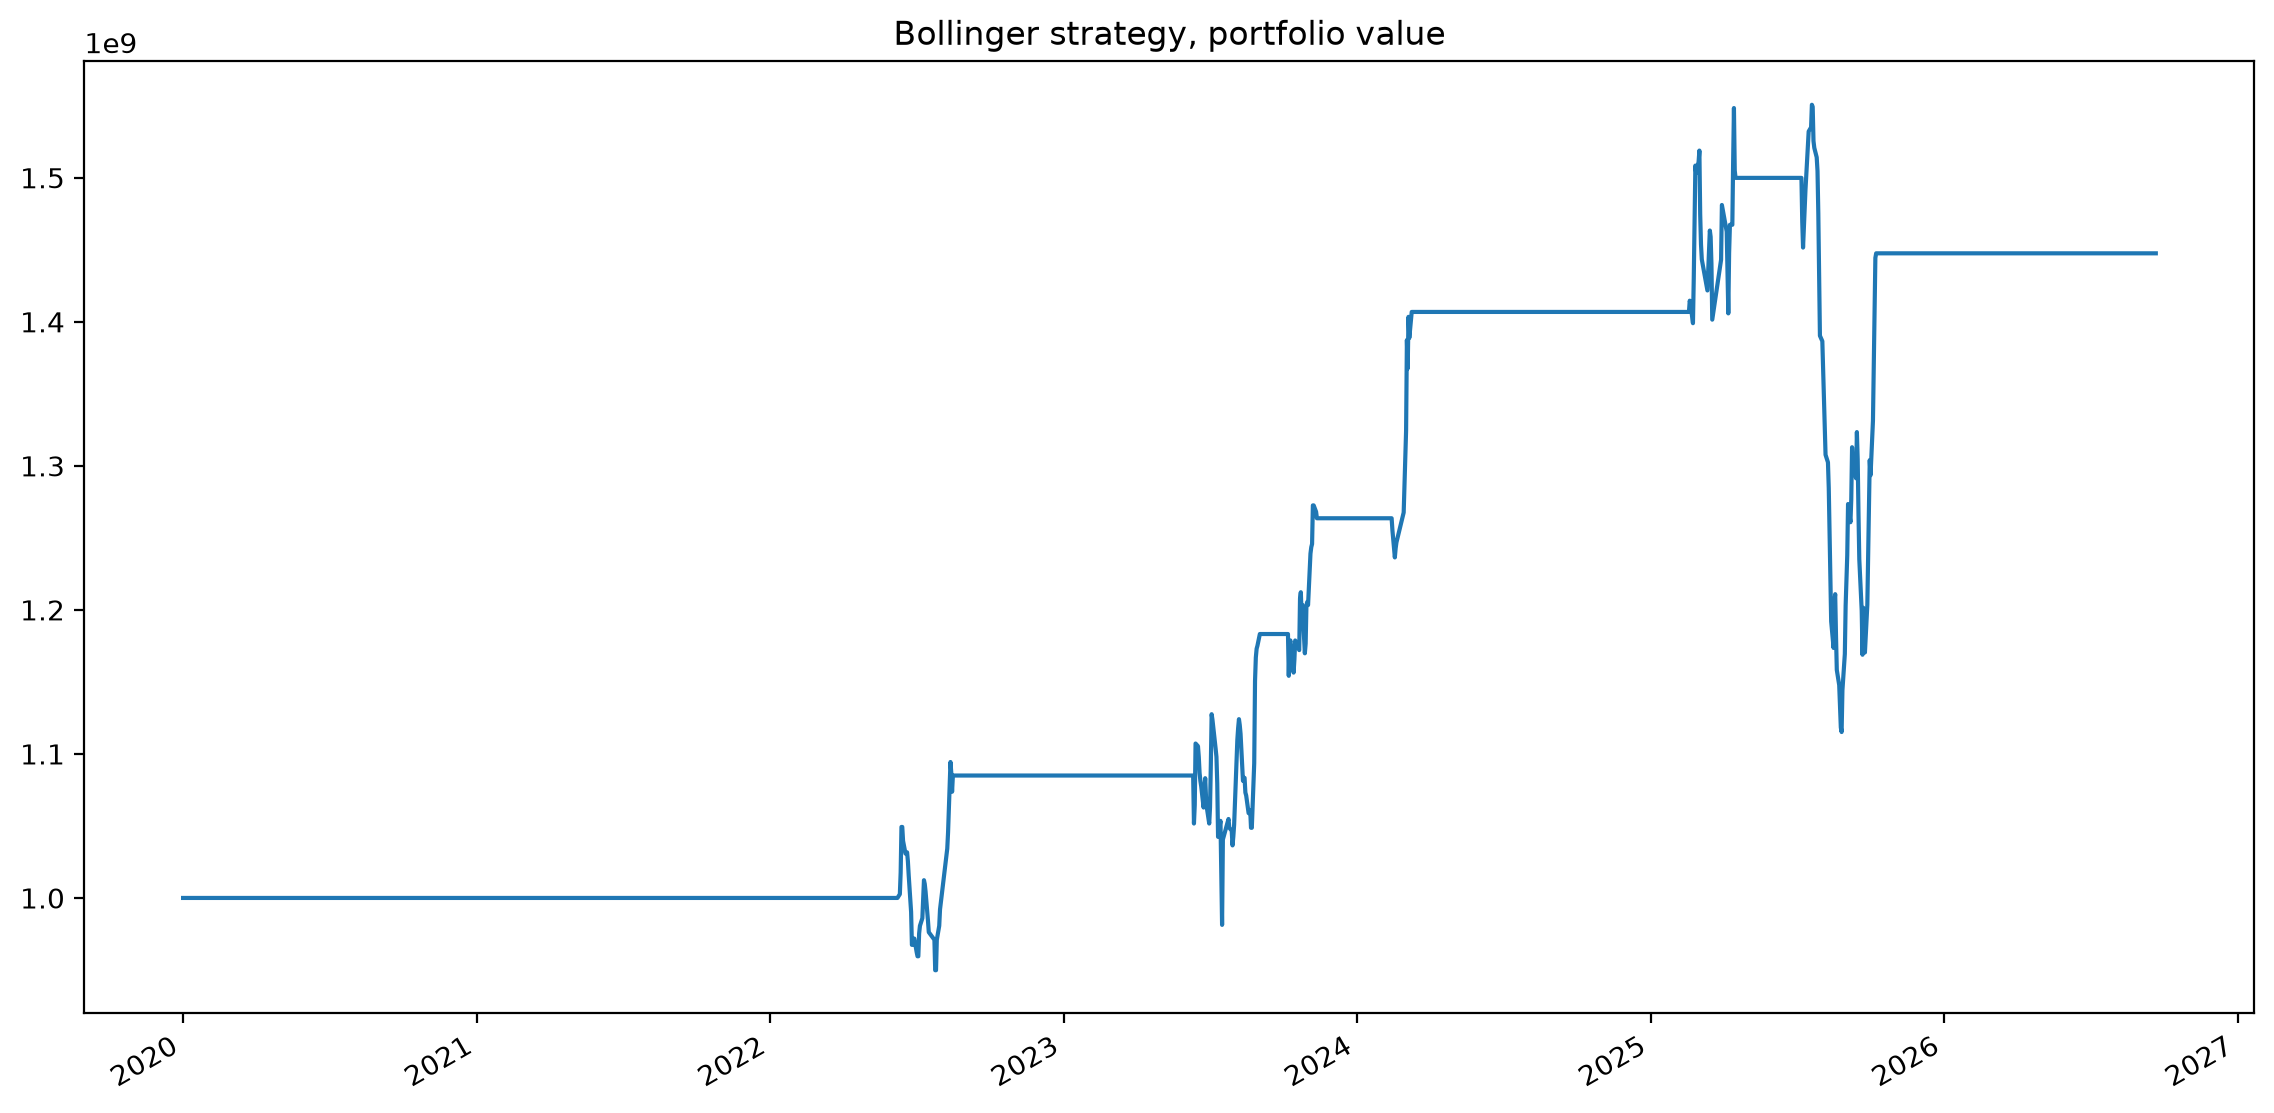

In [19]:
class BollingerSignal(bt.Strategy):
    params = (("period", 20), ("devfactor", 2.0))

    def __init__(self):
        bb = bt.ind.BollingerBands(period=self.p.period, devfactor=self.p.devfactor)
        self.buy_signal = bt.ind.CrossOver(self.data.close, bb.lines.bot)
        self.sell_signal = bt.ind.CrossOver(self.data.close, bb.lines.top)

    def next(self):
        if not self.position and self.buy_signal > 0:
            self.buy(size=int(self.broker.getcash() / self.data.open[0]))
        elif self.position and self.sell_signal < 0:
            self.sell(size=self.position.size)


final, bb_equity = run_backtest(BollingerSignal, bt_df)
print(f"Bollinger(20, 2): {final:,.0f} Rial")
bb_equity.plot(title="Bollinger strategy, portfolio value")
plt.show()

## 2.4 RSI and a long/short strategy

Long when the 14-session RSI crosses above 30, exit above 50; short when it crosses
below 70, exit below 50. `SignalStrategy` leaves position sizing to the sizer, which is
95% of equity per trade here; the book's default stake of one share would buy a single
30,000-Rial share against a billion in cash and draw a flat line. TSETMC has no short
selling, so the short leg is paper-only, exactly as the book's US example ignores
borrow costs.

RSI(14): 250,421,370 Rial


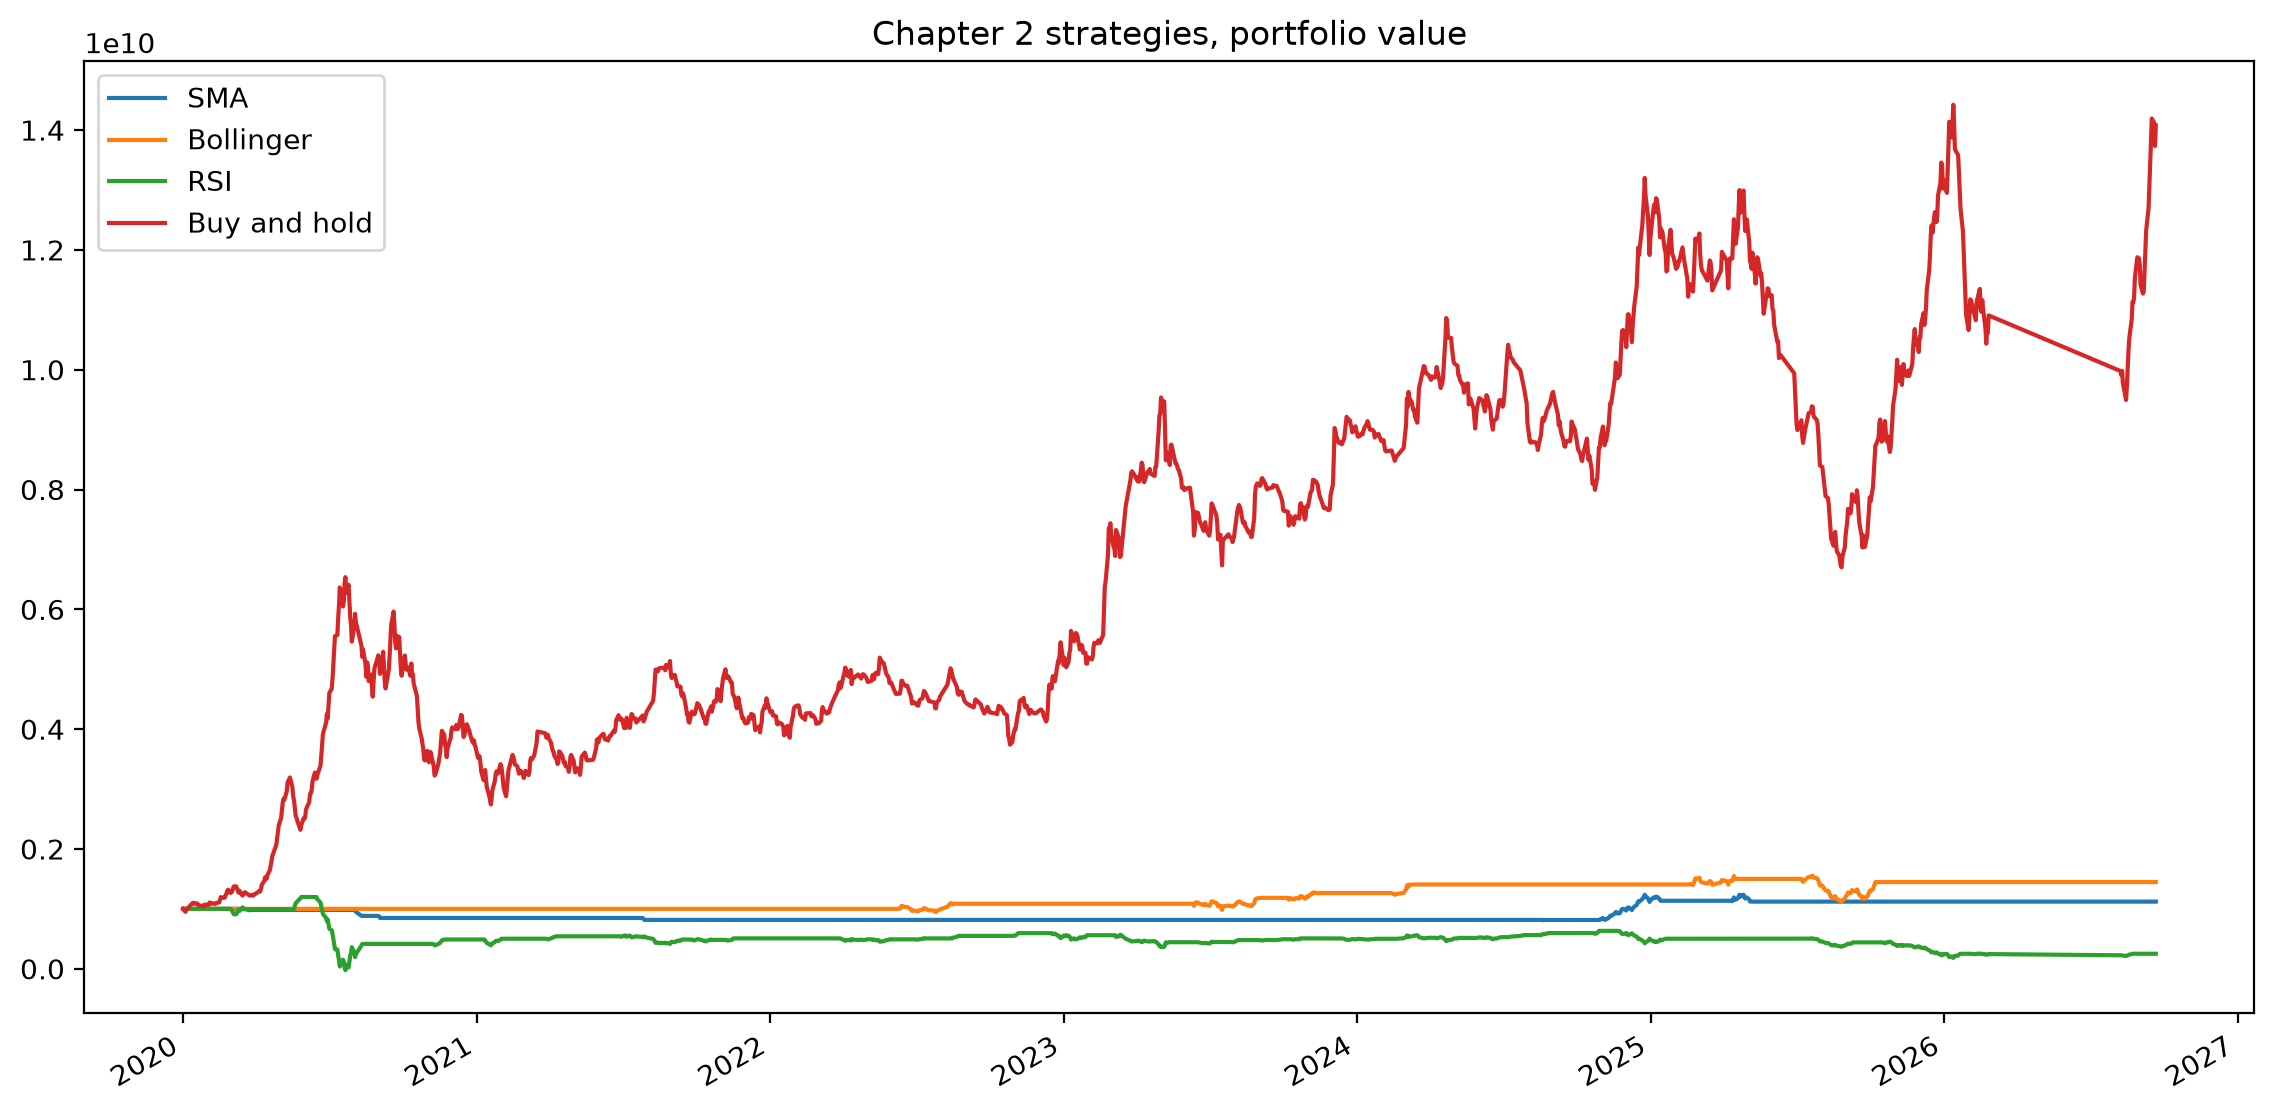

In [20]:
class RsiSignal(bt.SignalStrategy):
    params = dict(rsi_periods=14, rsi_upper=70, rsi_lower=30, rsi_mid=50)

    def __init__(self):
        rsi = bt.ind.RSI(period=self.p.rsi_periods, upperband=self.p.rsi_upper, lowerband=self.p.rsi_lower)
        self.signal_add(bt.SIGNAL_LONG, bt.ind.CrossUp(rsi, self.p.rsi_lower, plot=False))
        self.signal_add(bt.SIGNAL_LONGEXIT, -(rsi > self.p.rsi_mid))
        self.signal_add(bt.SIGNAL_SHORT, -bt.ind.CrossDown(rsi, self.p.rsi_upper, plot=False))
        self.signal_add(bt.SIGNAL_SHORTEXIT, rsi < self.p.rsi_mid)


final, rsi_equity = run_backtest(RsiSignal, bt_df)
print(f"RSI(14): {final:,.0f} Rial")
curves = {"SMA": sma_equity, "Bollinger": bb_equity, "RSI": rsi_equity, "Buy and hold": buy_hold}
ax = pd.DataFrame(curves).plot()
ax.set_title("Chapter 2 strategies, portfolio value")
plt.show()

# Chapter 7: Asset allocation

## 7.1 A basic 1/n portfolio

Four TSETMC stocks and two Nobitex pairs. `download()` returns the book's
`(Price, Ticker)` column layout and takes both kinds in one call; `dropna()` keeps the
days on which every asset traded, which is TSETMC's calendar (crypto's weekend rows
drop out). Returns are unit-free, so the Toman crypto columns need no rescaling here.
pyfolio does not run on current pandas, so the four headline metrics are computed by
hand.

(197, 6) 2025-05-12 -> 2026-09-21
annual return        242.67%
annual volatility     55.57%
sharpe (rf=0)        436.66%
max drawdown         -24.59%
dtype: str


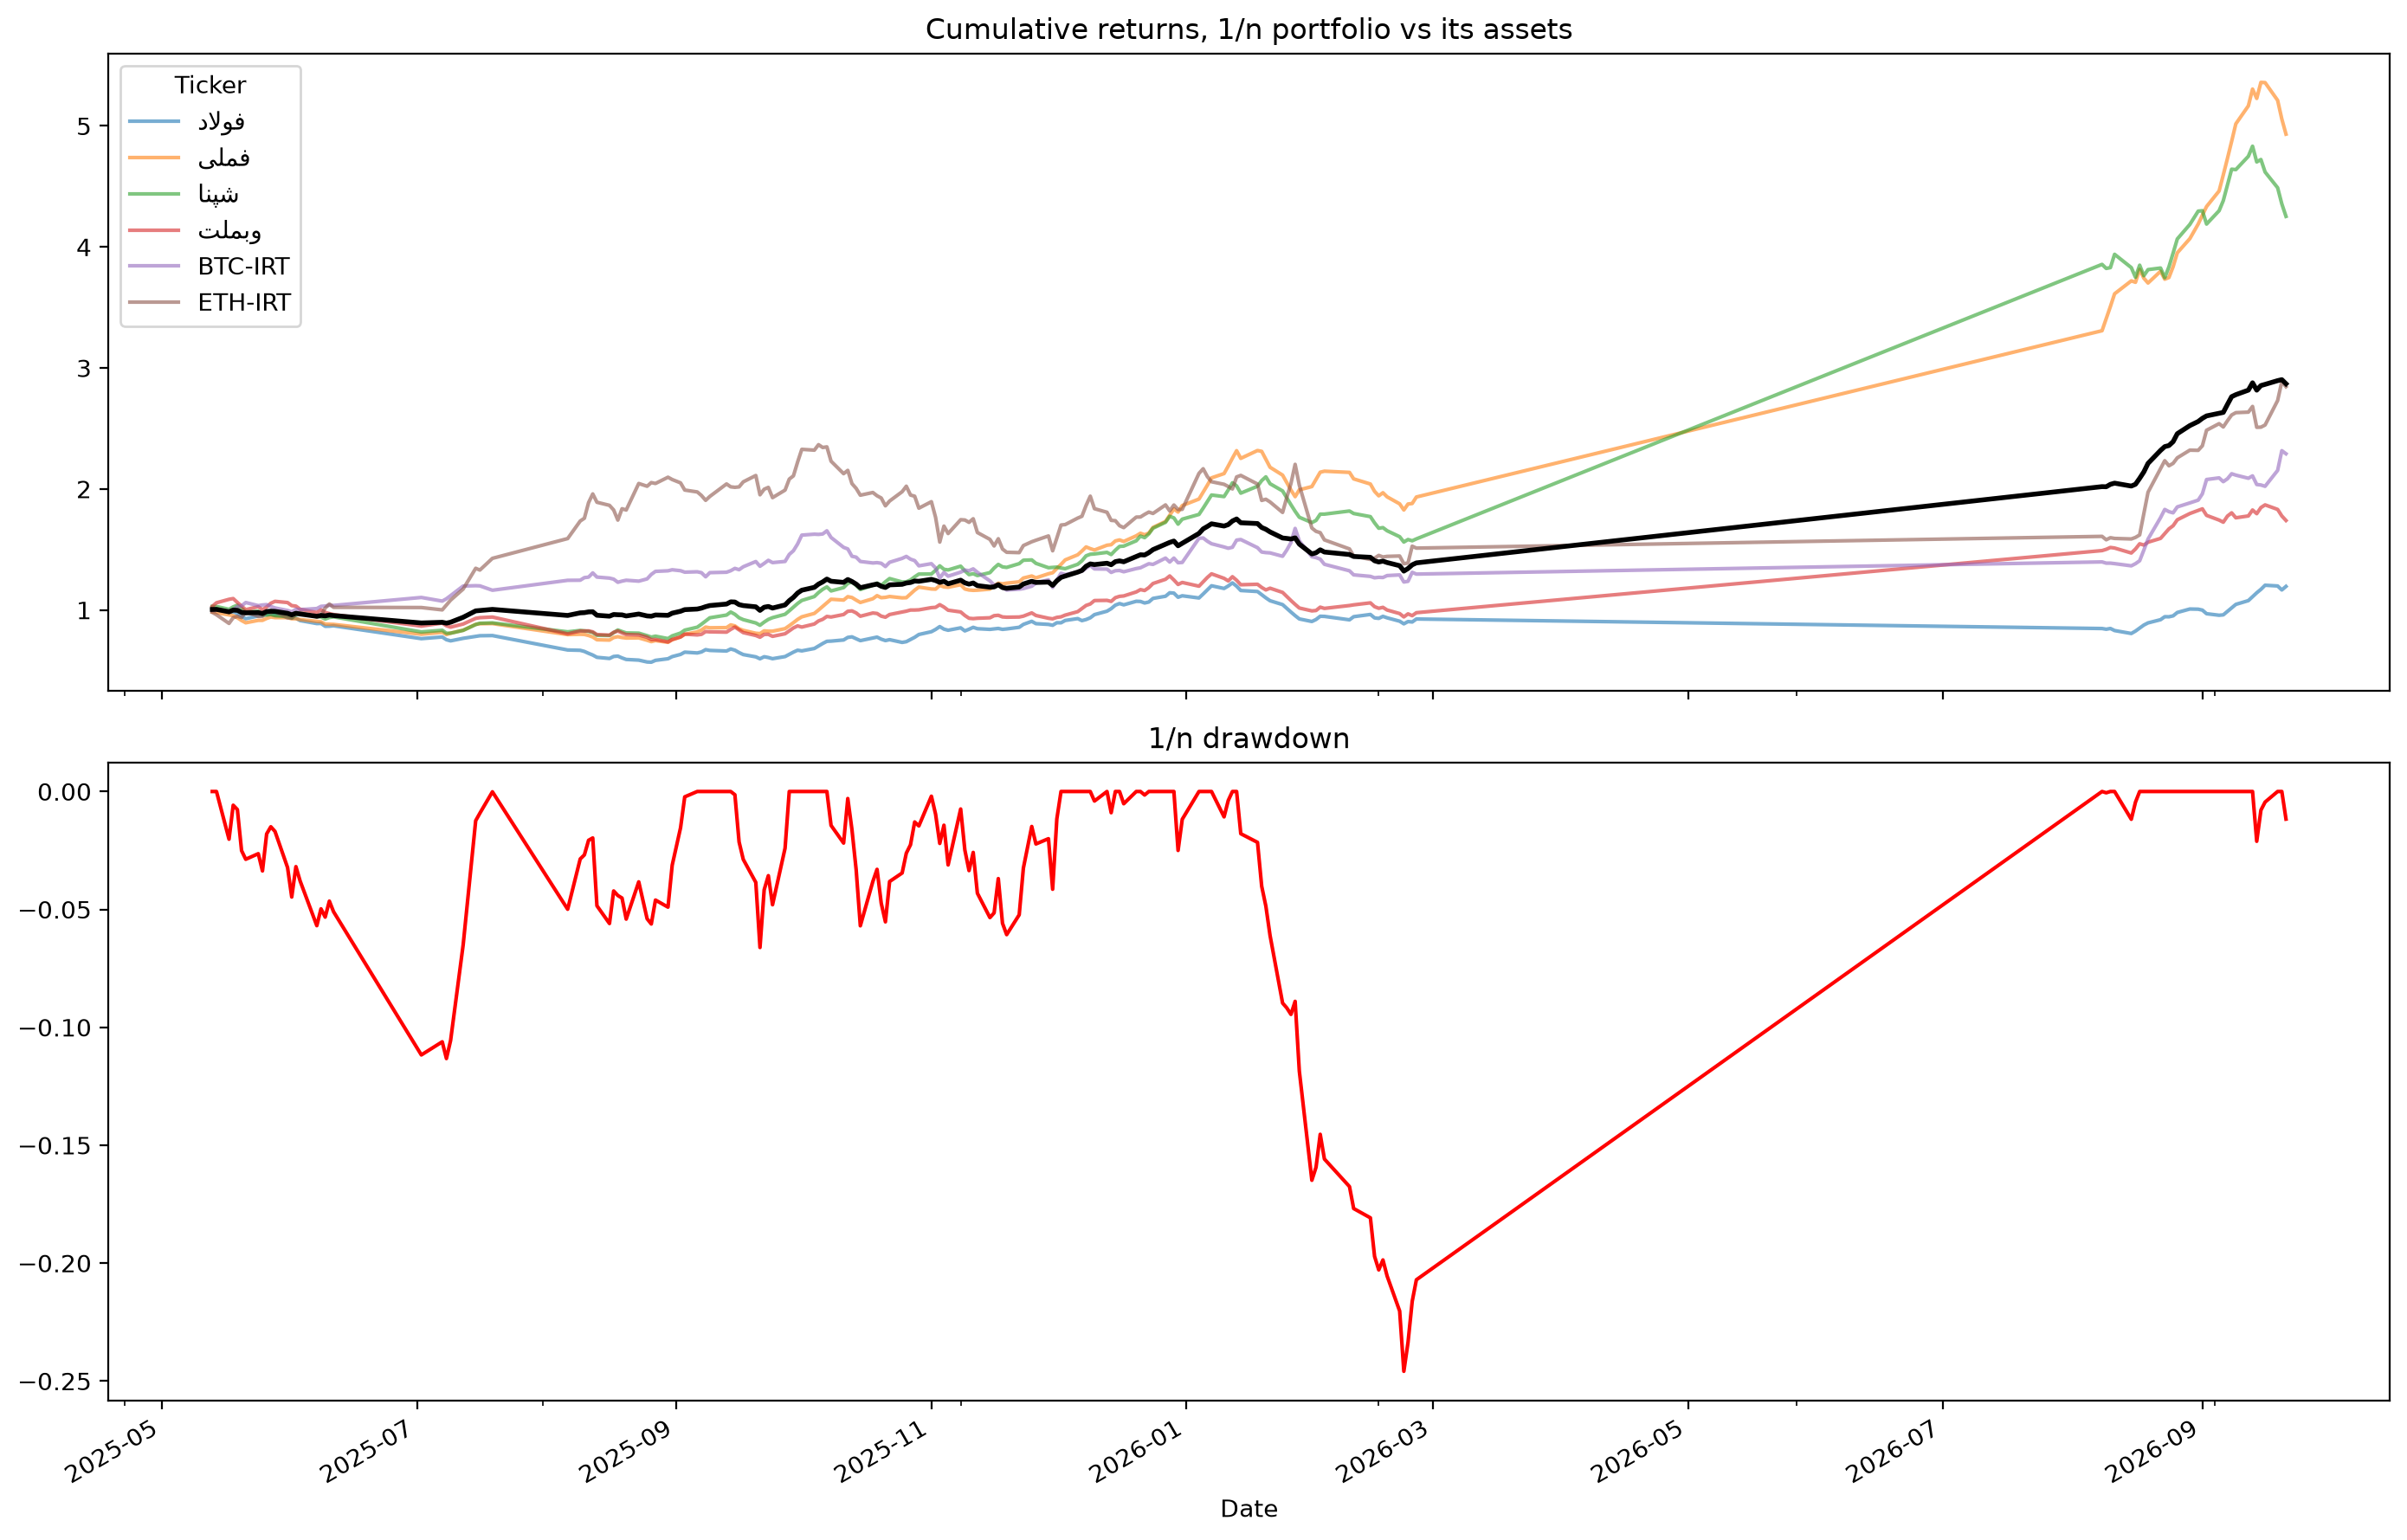

In [21]:
RISKY_ASSETS = ["فولاد", "فملی", "شپنا", "وبملت", "BTC-IRT", "ETH-IRT"]
prices = yf.download(RISKY_ASSETS, start="2020-01-01", progress=False)["Close"].dropna()
print(prices.shape, prices.index.min().date(), "->", prices.index.max().date())
returns = prices.pct_change().dropna()
n_assets = len(RISKY_ASSETS)
weights = np.full(n_assets, 1 / n_assets)
portfolio = pd.Series(returns.values @ weights, index=returns.index, name="1/n")


def performance(daily, n_days=N_DAYS):
    cum = (1 + daily).cumprod()
    years = len(daily) / n_days
    annual = cum.iloc[-1] ** (1 / years) - 1
    vol = daily.std() * np.sqrt(n_days)
    drawdown = (cum / cum.cummax() - 1).min()
    return pd.Series(
        {
            "annual return": annual,
            "annual volatility": vol,
            "sharpe (rf=0)": annual / vol,
            "max drawdown": drawdown,
        }
    )


print(performance(portfolio).map("{:.2%}".format))
fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
(1 + returns).cumprod().plot(ax=ax[0], alpha=0.6)
(1 + portfolio).cumprod().plot(ax=ax[0], color="black", linewidth=2)
ax[0].set_title("Cumulative returns, 1/n portfolio vs its assets")
cum = (1 + portfolio).cumprod()
(cum / cum.cummax() - 1).plot(ax=ax[1], color="red", title="1/n drawdown")
plt.tight_layout()
plt.show()

## 7.2 Efficient frontier by Monte Carlo

100,000 random long-only weight vectors over the six assets, annualised with the
measured session count, Sharpe with a zero risk-free rate (Iran publishes no daily
risk-free series). Over this window the crypto pairs are not the volatile end of the
chart: Rial devaluation lifts every asset, and the equities swing harder around it.
The max-Sharpe weights show how much bitcoin the frontier actually wants.

max Sharpe weights: {'فولاد': 0.22, 'فملی': 0.322, 'شپنا': 0.001, 'وبملت': 0.005, 'BTC-IRT': 0.28, 'ETH-IRT': 0.172}
min vol weights:    {'فولاد': 0.514, 'فملی': 0.034, 'شپنا': 0.003, 'وبملت': 0.097, 'BTC-IRT': 0.319, 'ETH-IRT': 0.034}


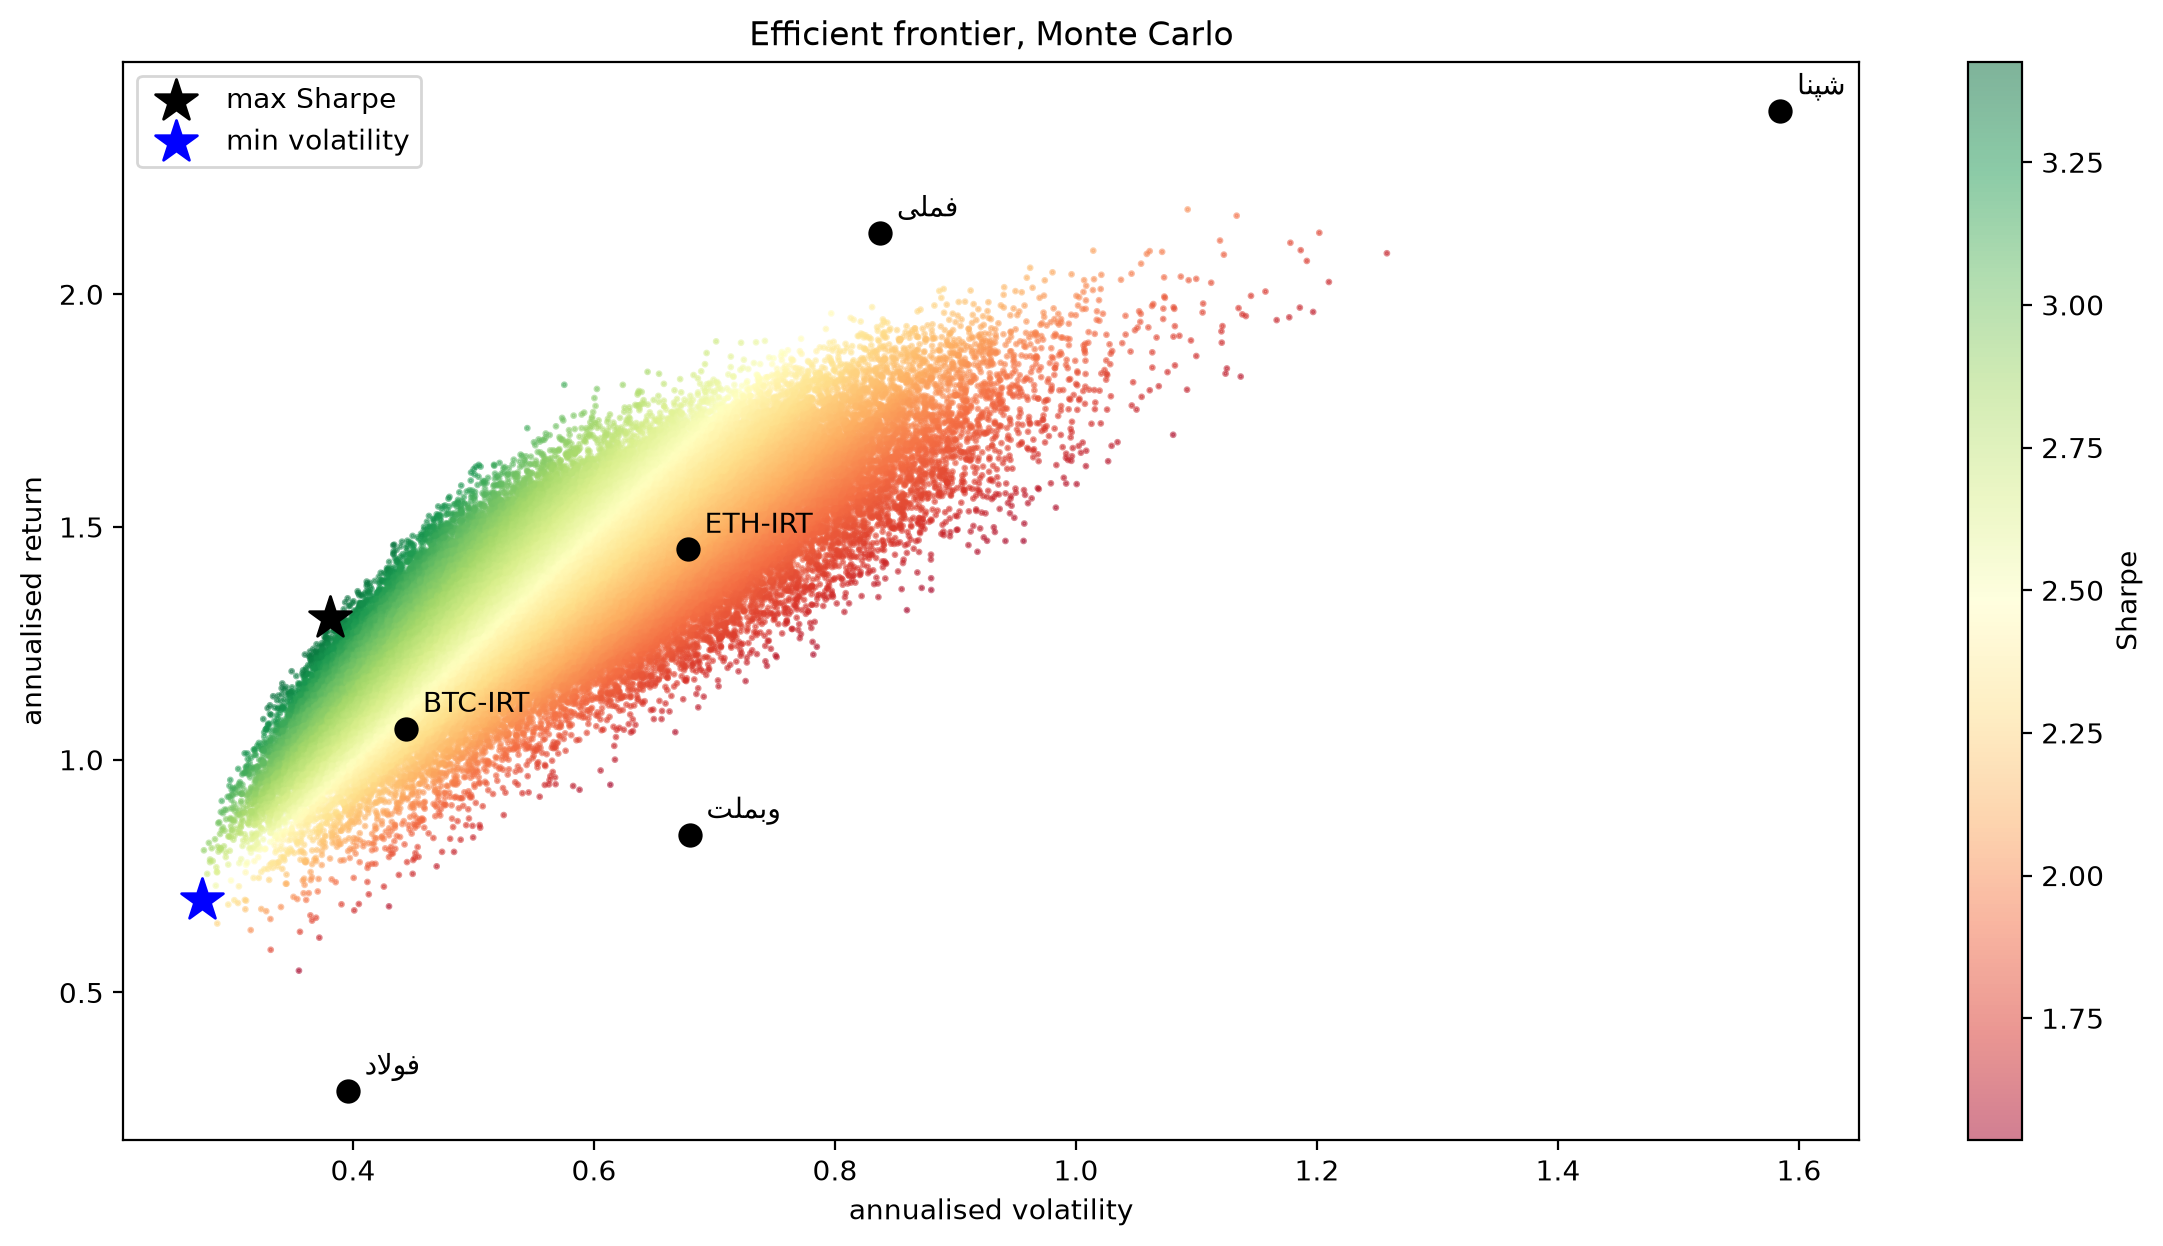

In [22]:
N_PORTFOLIOS = 10 ** 5
avg_returns = returns.mean() * N_DAYS
cov_mat = returns.cov() * N_DAYS

rng = np.random.default_rng(42)
w = rng.random((N_PORTFOLIOS, n_assets))
w /= w.sum(axis=1, keepdims=True)
p_rtn = w @ avg_returns.values
p_vol = np.sqrt(np.einsum("ij,jk,ik->i", w, cov_mat.values, w))
p_sharpe = p_rtn / p_vol
results = pd.DataFrame({"returns": p_rtn, "volatility": p_vol, "sharpe": p_sharpe})

max_sharpe = results.iloc[results["sharpe"].idxmax()]
min_vol = results.iloc[results["volatility"].idxmin()]
print("max Sharpe weights:", dict(zip(RISKY_ASSETS, w[results["sharpe"].idxmax()].round(3).tolist())))
print("min vol weights:   ", dict(zip(RISKY_ASSETS, w[results["volatility"].idxmin()].round(3).tolist())))

fig, ax = plt.subplots()
sc = ax.scatter(results["volatility"], results["returns"], c=results["sharpe"], cmap="RdYlGn", s=2, alpha=0.5)
ax.scatter(max_sharpe["volatility"], max_sharpe["returns"], marker="*",
           color="black", s=250, label="max Sharpe")
ax.scatter(min_vol["volatility"], min_vol["returns"], marker="*", color="blue", s=250, label="min volatility")
for i, asset in enumerate(RISKY_ASSETS):
    ax.scatter(np.sqrt(cov_mat.iloc[i, i]), avg_returns.iloc[i], marker="o", color="black", s=60)
    ax.annotate(asset, (np.sqrt(cov_mat.iloc[i, i]), avg_returns.iloc[i]),
                xytext=(6, 6), textcoords="offset points")
fig.colorbar(sc, label="Sharpe")
ax.set(xlabel="annualised volatility", ylabel="annualised return", title="Efficient frontier, Monte Carlo")
ax.legend()
plt.show()